# 05 — Feature Engineering

**Input:** bảng `public.cleaned_city_temperature` được bàn giao từ `03_data_cleaning.ipynb`.

**Output chính:** bảng `public.city_temperature_features` trong PostgreSQL. Các file `data/processed/feature_engineered_data.csv.gz`, `data/processed/feature_metadata.json`, `data/processed/feature_statistics.csv.gz` và `data/sample/feature_sample.csv` là bản bàn giao bổ sung cho kiểm tra và demo.

Notebook giữ nguyên grain **một thành phố tại một tháng**. Mỗi dòng được định danh bằng khóa nghiệp vụ `observation_date + city_name + country_name + latitude + longitude`; biến mục tiêu là `city_average_temperature`.

Kịch bản được chọn là **dự báo nhiệt độ trung bình kỳ vọng tại một tháng bất kỳ trong 12 tháng tương lai**. Tập feature triển khai chỉ dùng ngày mục tiêu, địa lý, quốc gia và thống kê khí hậu đã học; không tra cứu dòng của tháng mục tiêu và không yêu cầu người dùng nhập nhiệt độ cũ.


## 1. Mục tiêu, vai trò và pipeline Feature Engineering

### 1.1. Mục tiêu của Notebook

Notebook 05 biến tập dữ liệu đã làm sạch thành một tập **đặc trưng (feature)** có căn cứ, không rò rỉ dữ liệu và sẵn sàng cho huấn luyện mô hình. Các công việc chính gồm:

1. Chuyển các quan sát định lượng của Notebook 04 thành ý tưởng đặc trưng cụ thể, mỗi đặc trưng đều có lý do xuất phát từ EDA.
2. Xây dựng bảy nhóm đặc trưng ứng viên, đồng thời phân loại feature có thể tái tạo cho tương lai và feature chỉ phù hợp nghiên cứu lịch sử.
3. Đánh giá từng đặc trưng bằng tương quan tuyến tính, tương quan hạng, tỷ lệ phương sai giải thích và feature importance.
4. Kiểm tra và loại bỏ hai rủi ro đã được Notebook 04 chỉ ra: **rò rỉ dữ liệu (leakage)** và **đa cộng tuyến (multicollinearity)**.
5. Áp dụng cổng khả dụng triển khai: loại mọi feature cần quan sát ở/sau thời điểm hiện tại, kể cả khi feature đó có tương quan cao.
6. Lưu tập đặc trưng và metadata cho mô hình dự báo 1–12 tháng, gồm đầu vào số và hợp đồng one-hot encoding `country_name`.

### 1.2. Vai trò của Feature Engineering trong dự án

Notebook 04 cho thấy các biến thô trong bảng sạch **không phản ánh đúng bản chất khí hậu** của dữ liệu:

- `month` và `quarter` chỉ có tương quan tuyến tính `r ≈ 0.10` với nhiệt độ, dù biên độ mùa vụ lên tới **13.04 °C**. Nguyên nhân là quan hệ tháng–nhiệt độ có tính **tuần hoàn**: tháng 12 và tháng 1 liền kề về khí hậu nhưng cách xa nhau về mặt số học.
- `year` và `decade` chỉ có `r ≈ 0.048`, dù xu hướng ấm lên là thật ở mức **xấp xỉ +0,027 °C/năm**. Tín hiệu dài hạn này bị biên độ mùa vụ và biên độ vĩ độ (lớn hơn nhiều) che lấp.
- `latitude` là driver địa lý mạnh nhất (`r = -0.467`) nhưng vì có dấu, nó trộn lẫn hai thông tin khác nhau: khoảng cách tới xích đạo và bán cầu.

Feature Engineering là bước biểu diễn lại các thông tin đó dưới dạng mà mô hình học được: mã hóa tuần hoàn cho mùa vụ, biến trôi thời gian cho xu hướng, khoảng cách tuyệt đối tới xích đạo cho vĩ độ. Đây cũng là bước duy nhất trong pipeline chịu trách nhiệm **chặn rò rỉ dữ liệu** trước khi mô hình được huấn luyện.

### 1.3. Kiến trúc pipeline

```text
public.cleaned_city_temperature  (5.579.085 dòng × 32 cột)
   ↓ chỉ đọc 16 cột cần dùng từ PostgreSQL
Bảng làm việc theo grain City–month
   ↓ chia thời gian: feature-fit → validation → test
7 nhóm đặc trưng ứng viên: future-known + history-only
   ↓ đánh giá trên validation + cổng khả dụng triển khai
Kiểm tra leakage + multicollinearity
   ↓ bộ quy tắc lựa chọn định lượng
Danh sách feature biết trước tại tháng tương lai
   ↓
public.city_temperature_features + metadata + reference climatology
   ↓
Notebook 06 — temporal split + rolling-origin backtest 1–12 tháng
```

Các nguyên tắc thiết kế chính:

- **PostgreSQL là nguồn duy nhất.** Notebook dừng nếu thiếu `.env`, không kết nối được hoặc chưa có bảng sạch.
- **Test được khóa khỏi quá trình chọn feature.** Các metric và feature importance chỉ dùng validation 1984–1993; test 1994–2013 dành cho Notebook 06.
- **Target statistics chống self-target leakage.** Các dòng feature-fit dùng leave-one-out; validation/test chỉ dùng thống kê học từ giai đoạn kết thúc năm 1983.
- **Feature động chỉ nhìn quá khứ.** Lag nhiệt độ, chỉ số toàn cầu và uncertainty đều dùng tháng trước; không dùng phép đo của tháng đang dự báo.
- **Feature suy ra trực tiếp từ target không được xuất.** `temp_anomaly_vs_climatology` chỉ phục vụ insight ở Mục 8.


## 2. Chuẩn bị môi trường và cấu hình

### 2.1. Nạp các thư viện cần thiết

`pandas` và `numpy` phục vụ xây dựng đặc trưng; `matplotlib` và `seaborn` vẽ biểu đồ đánh giá; `SQLAlchemy` kết hợp `psycopg2` dùng để đọc/ghi PostgreSQL; `python-dotenv` nạp cấu hình từ `.env` mà không ghi mật khẩu vào notebook.

In [6]:
import gc
import json
import os
import shutil
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5.5)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'pandas {pd.__version__} · numpy {np.__version__}')

pandas 3.0.3 · numpy 2.4.6


Notebook chỉ dùng các thư viện đã có trong `requirements.txt`. `scikit-learn` là **tùy chọn**: nếu môi trường chưa cài, Mục 6.3 sẽ tự chuyển sang phương án đánh giá thuần `pandas`/`numpy` và notebook vẫn chạy hết.

### 2.2. Xác định thư mục dự án và đầu ra

Notebook có thể được mở từ thư mục gốc, `notebooks_v1/` hoặc `notebooks_v2/`. Hàm dưới tìm project root dựa trên hai thư mục ổn định `data/` và `SQL/`, sau đó chuẩn bị các thư mục đầu ra.

In [7]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa cả data/ và SQL/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'SQL').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và SQL/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
SAMPLE_DIR = PROJECT_ROOT / 'data' / 'sample'
REPORT_IMAGES_DIR = PROJECT_ROOT / 'reports' / 'images'
for directory in (PROCESSED_DIR, SAMPLE_DIR, REPORT_IMAGES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLEANED_TABLE = 'cleaned_city_temperature'
FEATURE_TABLE = 'city_temperature_features'
METADATA_PATH = PROCESSED_DIR / 'feature_metadata.json'
FEATURE_STATS_PATH = PROCESSED_DIR / 'feature_statistics.csv.gz'
SAMPLE_PATH = SAMPLE_DIR / 'feature_sample.csv'

print('Project root   :', PROJECT_ROOT)
print('Input table    :', f'public.{CLEANED_TABLE}')
print('Processed dir  :', PROCESSED_DIR)
print('Report images  :', REPORT_IMAGES_DIR)


Project root   : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis
Input table    : public.cleaned_city_temperature
Processed dir  : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed
Report images  : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images


Đường dẫn in ra phải trỏ tới đúng project hiện tại. Notebook không đọc, ghi hoặc thay đổi bất kỳ file nào trong `data/raw/`.

### 2.3. Tham số cấu hình của notebook

Notebook dùng các tham số sau để mọi bước có thể tái lập:

| Nhóm | Tham số chính | Vai trò |
|---|---|---|
| Chế độ chạy | `FAST_MODE`, `FAST_MODE_ROWS` | Chạy thử trên dữ liệu nhỏ; không dùng kết quả FAST_MODE cho báo cáo |
| Chia thời gian | `FEATURE_FIT_CUTOFF_YEAR`, `VALIDATION_START_YEAR`, `TRAIN_CUTOFF_YEAR` | Tách fit-stat, validation và test theo thời gian |
| Đánh giá | `EVAL_SAMPLE_ROWS`, `RANDOM_SEED` | Giới hạn chi phí tính toán và cố định kết quả lấy mẫu |
| Lựa chọn | `MIN_ETA_SQUARED`, `MIN_ABS_PEARSON`, `REDUNDANCY_THRESHOLD` | Loại feature yếu hoặc trùng lặp |
| Đầu ra | `FORECAST_HORIZON_MONTHS`, `OUTPUT_COMPRESSION` | Xác định horizon 12 tháng và định dạng file bàn giao |


#### 2.3.1. Chế độ chạy và mốc thời gian

`FAST_MODE` chỉ dùng kiểm tra nhanh. Ba mốc năm bảo đảm target statistics, validation và test không chồng lấn.


In [8]:
# --- Chế độ chạy ---------------------------------------------------------
FAST_MODE = False          # True: chạy thử nhanh trên một phần dữ liệu
FAST_MODE_ROWS = 400_000   # số dòng đầu theo thứ tự vị trí–thời gian

# --- Chia dữ liệu theo thời gian -----------------------------------------
FEATURE_FIT_CUTOFF_YEAR = 1983  # chỉ giai đoạn này được dùng để học target statistics
VALIDATION_START_YEAR = 1984    # validation: 1984–1993, dùng để chọn feature
TRAIN_CUTOFF_YEAR = 1993        # test: 1994–2013, tuyệt đối không dùng để chọn feature


#### 2.3.2. Tham số đánh giá và lựa chọn

Các ngưỡng được khai báo một lần để kết quả chọn feature có thể giải thích và tái lập.


In [9]:
# --- Đánh giá đặc trưng --------------------------------------------------
EVAL_SAMPLE_ROWS = 400_000
ETA_SQUARED_BINS = 20
RANDOM_SEED = 42

# --- Quy tắc lựa chọn đặc trưng (Mục 7) ---------------------------------
MIN_ETA_SQUARED = 0.005
MIN_ABS_PEARSON = 0.05
REDUNDANCY_THRESHOLD = 0.95


#### 2.3.3. Cấu hình đầu ra

Cell xác định target, horizon, nhóm feature được phép triển khai và đường dẫn file đầu ra.


In [10]:
# --- Đầu ra --------------------------------------------------------------
OUTPUT_COMPRESSION = 'gzip'
SAMPLE_ROWS = 50_000
TARGET_COLUMN = 'city_average_temperature'
FORECAST_HORIZON_MONTHS = 12
DEPLOYMENT_ALLOWED_AVAILABILITY = {'static', 'fit_stat'}
CATEGORICAL_FEATURES = ['country_name']

rng = np.random.default_rng(RANDOM_SEED)
OUTPUT_PATH = PROCESSED_DIR / (
    'feature_engineered_data.csv.gz' if OUTPUT_COMPRESSION == 'gzip'
    else 'feature_engineered_data.csv'
)

if not FEATURE_FIT_CUTOFF_YEAR < VALIDATION_START_YEAR <= TRAIN_CUTOFF_YEAR:
    raise ValueError('Các mốc fit/validation/train không đúng thứ tự thời gian.')

print(f'FAST_MODE                  : {FAST_MODE}')
print(f'FEATURE_FIT_CUTOFF_YEAR    : {FEATURE_FIT_CUTOFF_YEAR}')
print(f'VALIDATION_START_YEAR      : {VALIDATION_START_YEAR}')
print(f'TRAIN_CUTOFF_YEAR          : {TRAIN_CUTOFF_YEAR}')
print(f'EVAL_SAMPLE_ROWS           : {EVAL_SAMPLE_ROWS:,}')
print(f'Target                     : {TARGET_COLUMN}')
print(f'Phạm vi dự báo             : 1–{FORECAST_HORIZON_MONTHS} tháng tương lai')
print(f'Feature khả dụng triển khai: {sorted(DEPLOYMENT_ALLOWED_AVAILABILITY)}')
print(f'Feature phân loại          : {CATEGORICAL_FEATURES}')
print(f'Output                     : {OUTPUT_PATH.name}')


FAST_MODE                  : False
FEATURE_FIT_CUTOFF_YEAR    : 1983
VALIDATION_START_YEAR      : 1984
TRAIN_CUTOFF_YEAR          : 1993
EVAL_SAMPLE_ROWS           : 400,000
Target                     : city_average_temperature
Phạm vi dự báo             : 1–12 tháng tương lai
Feature khả dụng triển khai: ['fit_stat', 'static']
Feature phân loại          : ['country_name']
Output                     : feature_engineered_data.csv.gz


Nếu `FAST_MODE = True`, mọi số liệu in ra sau đó chỉ mang tính kiểm tra logic và **không được dùng cho báo cáo**. Kết quả chính thức phải chạy với `FAST_MODE = False`.

### 2.4. Kết nối PostgreSQL bắt buộc


Notebook 05 chỉ đọc dữ liệu từ `public.cleaned_city_temperature` trong PostgreSQL để tuân thủ pipeline đã thống nhất từ Notebook 02–04. Không có nhánh fallback CSV: nếu database không khả dụng, notebook dừng và báo rõ lỗi để tránh vô tình dùng một bản dữ liệu khác.

Tạo file `.env` ở project root từ `.env.example`:

```text
DB_HOST=localhost
DB_PORT=5432
DB_NAME=climate_db
DB_USER=postgres
DB_PASSWORD=<mật khẩu PostgreSQL trên máy đang chạy>
```


#### 2.4.1. Đọc cấu hình kết nối

Đọc `.env`, kiểm tra đủ năm biến kết nối và không hiển thị mật khẩu.


In [11]:
ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {ENV_PATH}. Notebook 05 chỉ đọc dữ liệu từ PostgreSQL.'
    )

from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

load_dotenv(ENV_PATH, override=False)
required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise ValueError(f'.env thiếu các biến: {missing_env}')


#### 2.4.2. Tạo SQLAlchemy engine

Engine chỉ phục vụ truy vấn đọc dữ liệu theo chunk ở Mục 3.


In [12]:
DB_ENGINE = create_engine(
    URL.create(
        drivername='postgresql+psycopg2',
        username=os.environ['DB_USER'],
        password=os.environ['DB_PASSWORD'],
        host=os.environ['DB_HOST'],
        port=int(os.environ['DB_PORT']),
        database=os.environ['DB_NAME'],
    ),
    pool_pre_ping=True,
    connect_args={'connect_timeout': 10},
)


#### 2.4.3. Kiểm tra database và bảng nguồn

Notebook chỉ tiếp tục khi bảng `public.cleaned_city_temperature` tồn tại.


In [13]:
check_sql = text(
    'SELECT current_database() AS database_name, '
    f"to_regclass('public.{CLEANED_TABLE}') IS NOT NULL AS source_table_exists"
)
with DB_ENGINE.connect() as connection:
    db_check = pd.read_sql_query(check_sql, connection)

display(db_check)
if not bool(db_check.loc[0, 'source_table_exists']):
    raise RuntimeError(
        f'Không tìm thấy public.{CLEANED_TABLE}. Hãy hoàn thành Notebook 03 trước.'
    )

DB_AVAILABLE = True
DATA_SOURCE = f'POSTGRESQL · public.{CLEANED_TABLE}'
print('PostgreSQL:', f"Đã kết nối {db_check.loc[0, 'database_name']}.public.{CLEANED_TABLE}")


,database_name,source_table_exists
0,climate_db,True


PostgreSQL: Đã kết nối climate_db.public.cleaned_city_temperature


Cell kết nối chỉ thực hiện truy vấn kiểm tra database và sự tồn tại của bảng nguồn; mật khẩu không được hiển thị. Notebook chỉ tiếp tục khi kết nối thành công và `public.cleaned_city_temperature` tồn tại.


## 3. Đọc dữ liệu đã làm sạch

### 3.1. Xác nhận data contract từ Notebook 03

Theo Notebook 03, bảng sạch phải có **5.579.085 dòng**, **32 cột**, **50 quốc gia**, thời gian từ `1863-01-01` đến `2013-09-01` và không còn dòng nào thiếu biến mục tiêu. Các hằng số dưới đây được dùng để đối chiếu sau khi nạp dữ liệu.

In [14]:
EXPECTED_CLEAN_ROWS = 5_579_085
EXPECTED_COUNTRIES = 50
EXPECTED_MIN_DATE = pd.Timestamp('1863-01-01')
EXPECTED_MAX_DATE = pd.Timestamp('2013-09-01')

BUSINESS_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
]
LOCATION_KEY_COLUMNS = ['city_name', 'country_name', 'latitude', 'longitude']

print(f'Kỳ vọng {EXPECTED_CLEAN_ROWS:,} dòng · {EXPECTED_COUNTRIES} quốc gia · '
      f'{EXPECTED_MIN_DATE.date()} → {EXPECTED_MAX_DATE.date()}')

Kỳ vọng 5,579,085 dòng · 50 quốc gia · 1863-01-01 → 2013-09-01


### 3.2. Chọn cột cần dùng và kiểu dữ liệu tối ưu

Bảng sạch có 32 cột nhưng Notebook 05 chỉ đọc **16 cột** để giảm thời gian truyền và bộ nhớ.

Các cột nhiệt độ cùng tháng chỉ được đọc khi cần chứng minh hoặc tạo phiên bản lag an toàn:

- `major_city_average_temperature` và `country_average_temperature` được dùng ở Mục 6.5 để chứng minh rò rỉ rồi loại.
- `land_average_temperature` chỉ là nguồn để tạo `land_temperature_lag_1`; bản cùng tháng không được đưa vào candidate feature.
- `city_average_temperature_uncertainty` chỉ là nguồn để tạo `city_uncertainty_lag_1`; uncertainty cùng tháng không được dùng dự báo.

Các biến `land_max_temperature`, `land_min_temperature` và `land_and_ocean_average_temperature` không cần đọc vì đều là bối cảnh cùng tháng, không biết trước cho một tháng tương lai.


In [15]:
CALENDAR_COLUMNS = ['year', 'month', 'quarter', 'decade']
TEMPERATURE_COLUMNS = [
    TARGET_COLUMN,                              # biến mục tiêu
    'city_average_temperature_uncertainty',     # nguồn tạo uncertainty lag 1
    'land_average_temperature',                 # nguồn tạo chỉ số toàn cầu lag 1
    'country_average_temperature',              # đọc để chứng minh rủi ro ở Mục 6.5
    'major_city_average_temperature',           # đọc để chứng minh rò rỉ ở Mục 6.5
]
FLAG_COLUMNS = ['is_major_city', 'city_temperature_iqr_outlier']

USED_COLUMNS = BUSINESS_KEY_COLUMNS + CALENDAR_COLUMNS + TEMPERATURE_COLUMNS + FLAG_COLUMNS

# Kiểu dữ liệu nhỏ nhất còn biểu diễn đúng giá trị (xem CHECK constraint của Notebook 03).
READ_DTYPES = {
    'year': 'int16', 'month': 'int8', 'quarter': 'int8', 'decade': 'int16',
    'city_name': 'category', 'country_name': 'category',
    'latitude': 'float32', 'longitude': 'float32',
    **{column: 'float32' for column in TEMPERATURE_COLUMNS},
}

print(f'Đọc {len(USED_COLUMNS)}/32 cột:')
for index, column in enumerate(USED_COLUMNS, start=1):
    print(f'  {index:2d}. {column}')

Đọc 16/32 cột:
   1. observation_date
   2. city_name
   3. country_name
   4. latitude
   5. longitude
   6. year
   7. month
   8. quarter
   9. decade
  10. city_average_temperature
  11. city_average_temperature_uncertainty
  12. land_average_temperature
  13. country_average_temperature
  14. major_city_average_temperature
  15. is_major_city
  16. city_temperature_iqr_outlier


`city_name` và `country_name` dùng `category` vì chỉ có 3.070 và 50 giá trị duy nhất trên hơn 5,5 triệu dòng — hạ từ chuỗi Python xuống mã số nguyên tiết kiệm phần lớn bộ nhớ của hai cột này. Các cột nhiệt độ dùng `float32` thay vì `float64`: dữ liệu gốc chỉ có 3 chữ số thập phân nên không mất thông tin, mà giảm một nửa bộ nhớ.

### 3.3. Nạp dữ liệu theo từng chunk

Dữ liệu được truy vấn từ PostgreSQL theo các chunk 500.000 dòng để giảm bộ nhớ đỉnh. Truy vấn có `ORDER BY country_name, city_name, latitude, longitude, observation_date`, giúp chuỗi của từng vị trí luôn đúng thứ tự trước khi tạo lag.


#### 3.3.1. Hàm chuẩn hóa từng chunk

Mỗi chunk được đổi ngày và dtype trước khi ghép để giảm bộ nhớ.


In [16]:
CHUNK_SIZE = 500_000


def compact_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Chuẩn hóa kiểu dữ liệu của một chunk trước khi ghép DataFrame lớn."""
    chunk['observation_date'] = pd.to_datetime(
        chunk['observation_date'], errors='raise'
    )
    for column, dtype in READ_DTYPES.items():
        if column in chunk.columns and chunk[column].dtype.name != dtype:
            chunk[column] = chunk[column].astype(dtype)
    for column in FLAG_COLUMNS:
        if chunk[column].dtype != bool:
            chunk[column] = chunk[column].astype('bool')
    return chunk


#### 3.3.2. Tạo truy vấn và đọc theo chunk

Truy vấn sắp xếp theo location–time để các phép tạo lag phía sau luôn đúng thứ tự.


In [17]:
limit_clause = f' LIMIT {FAST_MODE_ROWS}' if FAST_MODE else ''
query = text(
    f"SELECT {', '.join(USED_COLUMNS)} FROM public.{CLEANED_TABLE} "
    'ORDER BY country_name, city_name, latitude, longitude, observation_date'
    f'{limit_clause}'
)

parts = []
with DB_ENGINE.connect() as connection:
    for chunk in pd.read_sql_query(query, connection, chunksize=CHUNK_SIZE):
        parts.append(compact_chunk(chunk))

if not parts:
    raise RuntimeError(f'public.{CLEANED_TABLE} không có dữ liệu.')


#### 3.3.3. Ghép dữ liệu và xử lý FAST_MODE

Khi chạy nhanh, location cuối bị cắt dở được loại khỏi mẫu.


In [18]:
feature_df = pd.concat(parts, ignore_index=True)[USED_COLUMNS]

# LIMIT có thể cắt dở chuỗi của vị trí cuối. Loại vị trí đó trước mọi phép
# chia thời gian để DataFrame và các mask luôn cùng chỉ mục.
if FAST_MODE:
    last_location = feature_df.iloc[-1][LOCATION_KEY_COLUMNS]
    last_location_mask = pd.Series(True, index=feature_df.index)
    for column in LOCATION_KEY_COLUMNS:
        last_location_mask &= feature_df[column].eq(last_location[column])
    if (~last_location_mask).any():
        feature_df = feature_df.loc[~last_location_mask].reset_index(drop=True)

print(f'Nguồn dữ liệu : {DATA_SOURCE}')
print(f'Đã nạp        : {len(feature_df):,} dòng × {feature_df.shape[1]} cột')


Nguồn dữ liệu : POSTGRESQL · public.cleaned_city_temperature
Đã nạp        : 5,579,085 dòng × 16 cột


Dòng `Nguồn dữ liệu` phải luôn là `POSTGRESQL · public.cleaned_city_temperature`. Số cột đọc vào phải bằng 16; nếu kết nối hoặc data contract sai, notebook dừng thay vì chuyển nguồn.


### 3.4. Kiểm tra data contract, grain và bộ nhớ

Trước khi xây dựng đặc trưng, notebook kiểm tra ba điều kiện. Hai điều kiện đầu là **lỗi cấu trúc** và sẽ làm dừng notebook, vì mọi đặc trưng trễ phía sau đều dựa vào giả định grain duy nhất:

1. Khóa nghiệp vụ City–month phải duy nhất.
2. Biến mục tiêu không được có giá trị thiếu.

Điều kiện thứ ba — row count, số quốc gia, khoảng thời gian — chỉ **cảnh báo**, vì `FAST_MODE` cố tình đọc ít dòng hơn và người dùng có thể chạy lại pipeline với phạm vi khác.

#### 3.4.1. Kiểm tra grain và target

Dòng trùng khóa hoặc thiếu target làm dừng notebook vì sẽ khiến feature lịch sử sai.


In [19]:
duplicate_key_rows = int(feature_df.duplicated(subset=BUSINESS_KEY_COLUMNS).sum())
missing_target_rows = int(feature_df[TARGET_COLUMN].isna().sum())
if duplicate_key_rows:
    raise RuntimeError(
        f'Có {duplicate_key_rows:,} dòng trùng khóa nghiệp vụ City–month. '
        'Đặc trưng trễ yêu cầu grain duy nhất; hãy kiểm tra lại Notebook 03.'
    )
if missing_target_rows:
    raise RuntimeError(
        f'Có {missing_target_rows:,} dòng thiếu {TARGET_COLUMN}. '
        'Notebook 03 phải loại các dòng này trước khi bàn giao.'
    )


#### 3.4.2. Đối chiếu data contract

Báo cáo so sánh số dòng, quốc gia và khoảng ngày với Notebook 03.


In [20]:
actual_countries = int(feature_df['country_name'].nunique())
actual_locations = int(feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True).ngroups)
contract_report = pd.DataFrame(
    {
        'Expected': [EXPECTED_CLEAN_ROWS, EXPECTED_COUNTRIES,
                     EXPECTED_MIN_DATE.date(), EXPECTED_MAX_DATE.date()],
        'Actual': [len(feature_df), actual_countries,
                   feature_df['observation_date'].min().date(),
                   feature_df['observation_date'].max().date()],
    },
    index=['Row count', 'Country count', 'Min observation date', 'Max observation date'],
)
contract_report['Match'] = contract_report['Expected'].astype(str) == contract_report['Actual'].astype(str)
display(contract_report)

print(f'Số vị trí (city+country+toạ độ): {actual_locations:,}')
print(f'Bộ nhớ đang dùng               : '
      f'{feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
print(f'Khóa nghiệp vụ duy nhất        : PASS ({duplicate_key_rows} dòng trùng)')
print(f'Biến mục tiêu đầy đủ           : PASS ({missing_target_rows} dòng thiếu)')

if not contract_report['Match'].all():
    if FAST_MODE:
        print('\nLƯU Ý: FAST_MODE đang bật nên row count nhỏ hơn contract là bình thường.')
    else:
        print('\nCẢNH BÁO: dữ liệu không khớp contract của Notebook 03. '
              'Hãy kiểm tra lại phiên bản bảng sạch trước khi dùng kết quả cho báo cáo.')


,Expected,Actual,Match
Row count,5579085,5579085,True
Country count,50,50,True
Min observation date,1863-01-01,1863-01-01,True
Max observation date,2013-09-01,2013-09-01,True


Số vị trí (city+country+toạ độ): 3,119
Bộ nhớ đang dùng               : 400.5 MB
Khóa nghiệp vụ duy nhất        : PASS (0 dòng trùng)
Biến mục tiêu đầy đủ           : PASS (0 dòng thiếu)


Hai dòng `PASS` xác nhận grain City–month duy nhất và biến mục tiêu đầy đủ — đây là điều kiện bắt buộc để các đặc trưng trễ ở Mục 5.6 tra cứu đúng theo lịch. Bộ nhớ in ra nên ở mức vài trăm MB nhờ các kiểu dữ liệu đã hạ ở Mục 3.2; nếu con số này lên tới nhiều GB, rất có thể `READ_DTYPES` chưa được áp dụng.

In [21]:
display(feature_df.head())
display(feature_df.dtypes.to_frame('dtype'))

,observation_date,city_name,country_name,latitude,longitude,year,month,quarter,decade,city_average_temperature,city_average_temperature_uncertainty,land_average_temperature,country_average_temperature,major_city_average_temperature,is_major_city,city_temperature_iqr_outlier
0,1863-01-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,1,1,1860,20.3650,2.9650,3.0340,20.2260,NaN,False,False
1,1863-02-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,2,1,1860,20.3580,3.0540,3.2530,19.5130,NaN,False,False
2,1863-03-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,3,1,1860,16.6370,1.6250,4.6820,16.4700,NaN,False,False
3,1863-04-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,4,2,1860,13.9310,1.6410,7.9310,13.5310,NaN,False,False
4,1863-05-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,5,2,1860,9.1430,1.6530,11.0810,9.0090,NaN,False,False


,dtype
observation_date,datetime64[s]
city_name,str
country_name,str
latitude,float32
longitude,float32
year,int16
month,int8
quarter,int8
decade,int16
city_average_temperature,float32


Bảng mẫu cho thấy dữ liệu đã ở đúng grain City–month với các cột nghiệp vụ trực tiếp. Cột `major_city_average_temperature` phần lớn là `NaN` — đúng như Notebook 04 mô tả: chỉ khoảng 2,7% dòng thuộc nhóm Major City.

## 4. Ý tưởng xây dựng Feature từ kết quả EDA

### 4.1. Chuyển kết quả EDA thành ý tưởng Feature

Mỗi feature phải trả lời được ba câu hỏi: **mang thông tin gì**, **có biết tại thời điểm dự báo không**, và **có gây leakage không**. Notebook tạo feature ứng viên theo bảy nhóm rồi chỉ giữ những feature có thể tái tạo khi người dùng chọn một tháng tương lai.


#### 4.1.1. Feature biểu diễn chu kỳ thời gian

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `month_sin`, `month_cos` | `sin(2πm/12)`, `cos(2πm/12)` | Biểu diễn tháng trên đường tròn, giúp tháng 12 gần tháng 1 |
| `climatic_month_sin`, `climatic_month_cos` | Sin/cos sau khi dịch pha Nam bán cầu 6 tháng | Đồng bộ mùa nóng–lạnh giữa hai bán cầu |
| `years_since_start` | `year - 1863` | Biểu diễn xu hướng dài hạn |

Sin và cos phải đi thành cặp. Chỉ dùng một thành phần sẽ làm mất thông tin vị trí trên chu kỳ 12 tháng.


#### 4.1.2. Feature địa lý

| Feature | Ý nghĩa |
|---|---|
| `latitude` | Phân biệt vị trí Bắc/Nam bán cầu |
| `abs_latitude` | Khoảng cách tới xích đạo, liên quan trực tiếp tới nền nhiệt |
| `hemisphere_north` | Cờ bán cầu để hỗ trợ diễn giải mùa vụ |
| `longitude` | Bổ sung vị trí theo hướng Đông–Tây |
| `is_major_city` | Feature ứng viên để kiểm tra, chỉ giữ nếu có tín hiệu đủ mạnh |

`latitude_zone` chỉ phục vụ phân tích; model dùng giá trị vĩ độ trực tiếp để tránh mã hóa trùng thông tin.


#### 4.1.3. Feature tương tác thời gian–địa lý

| Feature | Công thức | Mục đích |
|---|---|---|
| `abslat_x_month_sin` | `abs_latitude × climatic_month_sin` | Cho phép biên độ mùa thay đổi theo vĩ độ |
| `abslat_x_month_cos` | `abs_latitude × climatic_month_cos` | Bổ sung thành phần còn lại của chu kỳ mùa |
| `abslat_x_years` | `abs_latitude × years_since_start` | Kiểm tra xu hướng dài hạn có khác theo vĩ độ hay không |

Các tích tương tác giúp Linear Regression biểu diễn quan hệ mà từng feature riêng lẻ không mô tả được.


#### 4.1.4. Feature khí hậu chuẩn theo địa điểm

| Feature | Cách tính an toàn | Ý nghĩa |
|---|---|---|
| `loc_month_climatology` | Trung bình `(location, month)` chỉ từ giai đoạn feature-fit | Nền nhiệt bình thường của thành phố trong tháng tương ứng |
| `loc_mean_temperature` | Trung bình dài hạn theo location | Nền nhiệt chung của thành phố |
| `loc_temperature_std` | Độ lệch chuẩn theo location | Mức biến động khí hậu của thành phố |

Với dòng thuộc feature-fit, notebook dùng **leave-one-out** để target của chính dòng đó không tham gia feature. Validation và test chỉ tra thống kê đã cố định từ giai đoạn trước.


#### 4.1.5. Feature lịch sử, độ trễ và cửa sổ trượt

Notebook tạo `temp_lag_1`, `temp_lag_12`, `temp_roll_mean_12`, `temp_roll_std_12` và `temp_anomaly_lag_12` để đánh giá tín hiệu lịch sử. Các feature này **không được triển khai** vì ứng dụng hiện không có chuỗi quan trắc cập nhật từ 2013 đến forecast origin. Giữ chúng trong bước nghiên cứu giúp chứng minh rằng tín hiệu mạnh chưa đồng nghĩa với khả năng sử dụng thực tế.


#### 4.1.6. Feature bối cảnh khí hậu toàn cầu

`land_temperature_lag_1` và `land_anomaly_lag_1` dùng nhiệt độ đất toàn cầu của tháng trước. Chúng chỉ phục vụ đánh giá lịch sử; nguồn dự án dừng ở năm 2013 nên không có giá trị cập nhật tại thời điểm người dùng dự báo.


#### 4.1.7. Feature chất lượng phép đo

`city_uncertainty_lag_1` là độ bất định của phép đo tháng trước. Uncertainty cùng tháng bị loại vì chỉ xuất hiện khi target đã được quan trắc; phiên bản lag cũng không được triển khai do thiếu dữ liệu cập nhật sau năm 2013.


#### 4.1.8. Nguyên tắc chọn feature cuối

| Điều kiện | Quyết định |
|---|---|
| Không biết tại thời điểm dự báo | Loại khỏi model triển khai |
| Suy ra từ target hoặc dữ liệu cùng tháng | Loại vì leakage |
| Gần như hằng số hoặc tín hiệu dưới ngưỡng | Loại |
| Tương quan tuyệt đối với feature khác vượt `0.95` | Giữ feature có tín hiệu mạnh hơn |
| Thuộc cặp sin/cos hoặc xu hướng thời gian cần thiết | Giữ theo ràng buộc nghiệp vụ |


### 4.2. Nguyên tắc chống rò rỉ dữ liệu

Rò rỉ dữ liệu là việc dùng thông tin không có tại thời điểm dự báo hoặc để test tác động ngược vào quá trình xây dựng mô hình. Notebook áp dụng sáu nguyên tắc:

1. Không dùng nhiệt độ hay uncertainty của chính tháng đang dự báo.
2. Chia dữ liệu theo thời gian thành feature-fit, validation và test; test không được dùng để đánh giá/chọn feature.
3. Target statistics dùng leave-one-out cho chính các dòng feature-fit; validation/test chỉ dùng thống kê cố định từ feature-fit.
4. Lag và rolling tra cứu đúng tháng lịch sử để đánh giá, nhưng không được xuất cho sản phẩm nếu backend không có lịch sử gần forecast origin.
5. Feature suy ra trực tiếp từ target chỉ dùng phân tích và không xuất sang Notebook 06.
6. Danh sách triển khai chỉ nhận `static` và `fit_stat`; kiểm tra tự động phải thất bại nếu còn feature `history`.

Mục 6.5 kiểm tra tự động các điều kiện quan trọng này.


### 4.3. Khai báo giai đoạn train và sổ đăng ký đặc trưng

Ba mask thời gian có vai trò riêng:

- `feature_fit_mask`: dữ liệu đến 1983 để học target statistics.
- `validation_period_mask`: 1984–1993 để đo và chọn feature.
- `test_period_mask`: 1994–2013, được khóa khỏi mọi quyết định feature.

Hàm `add_feature` ghi feature vào DataFrame và đăng ký metadata. Trường `availability` cho biết điều kiện dùng lúc dự báo:

- `static`: suy ra từ địa điểm và ngày dự báo.
- `fit_stat`: cần bảng thống kê học từ feature-fit và phải lưu cùng mô hình.
- `history`: cần dữ liệu các tháng trước của đúng địa điểm hoặc chuỗi toàn cầu.


#### 4.3.1. Tạo các mask thời gian

Tách feature-fit, validation và test trước khi học bất kỳ thống kê nào từ target.


In [22]:
feature_fit_mask = feature_df['year'] <= FEATURE_FIT_CUTOFF_YEAR
validation_period_mask = feature_df['year'].between(
    VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR
)
test_period_mask = feature_df['year'] > TRAIN_CUTOFF_YEAR
train_period_mask = feature_fit_mask | validation_period_mask

if (feature_fit_mask & validation_period_mask).any():
    raise RuntimeError('Giai đoạn feature-fit và validation bị chồng lấn.')
if (train_period_mask & test_period_mask).any():
    raise RuntimeError('Giai đoạn train và test bị chồng lấn.')
if not (feature_fit_mask | validation_period_mask | test_period_mask).all():
    raise RuntimeError('Có dòng chưa được gán vào fit/validation/test.')


#### 4.3.2. Hàm đăng ký feature

`add_feature()` thêm cột và lưu metadata tối thiểu: nhóm, mô tả, khả dụng và dtype.


In [23]:
FEATURE_CATALOG: dict[str, dict] = {}


def add_feature(
    name: str,
    values,
    group: str,
    description: str,
    availability: str = 'static',
    force_keep: bool = False,
    keep_reason: str = '',
) -> None:
    """Ghi một đặc trưng vào feature_df và đăng ký metadata của nó."""
    series = pd.Series(np.asarray(values), index=feature_df.index)
    if series.dtype == bool:
        series = series.astype('int8')
    elif series.dtype.kind == 'f':
        series = series.astype('float32')
    elif series.dtype.kind in 'iu':
        max_abs = series.abs().max()
        series = series.astype('int32' if max_abs > 32_000 else 'int16')
    feature_df[name] = series
    FEATURE_CATALOG[name] = {
        'group': group,
        'description': description,
        'availability': availability,
        'force_keep': force_keep,
        'keep_reason': keep_reason,
        'dtype': str(series.dtype),
    }


#### 4.3.3. Kiểm tra phân chia dữ liệu

Bảng cho biết số dòng của từng giai đoạn; test chỉ dành cho Notebook 06.


In [24]:
split_summary = pd.DataFrame(
    {
        'Giai đoạn': ['Feature fit', 'Validation', 'Test'],
        'Khoảng năm': [
            f'<= {FEATURE_FIT_CUTOFF_YEAR}',
            f'{VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}',
            f'> {TRAIN_CUTOFF_YEAR}',
        ],
        'Số dòng': [
            int(feature_fit_mask.sum()),
            int(validation_period_mask.sum()),
            int(test_period_mask.sum()),
        ],
    }
)
split_summary['Tỷ lệ'] = split_summary['Số dòng'] / len(feature_df)
display(split_summary)


,Giai đoạn,Khoảng năm,Số dòng,Tỷ lệ
0,Feature fit,<= 1983,4468327,0.8009
1,Validation,1984–1993,374280,0.0671
2,Test,> 1993,736478,0.1320


Tỷ lệ dòng train in ra thường cao hơn tỷ lệ số năm, vì Notebook 04 đã chỉ ra độ phủ dữ liệu tăng dần theo thời gian (năm 1863 chỉ có 28.650 dòng). Nếu tỷ lệ test quá nhỏ so với nhu cầu đánh giá, hãy hạ `TRAIN_CUTOFF_YEAR` ở Mục 2.3 và chạy lại từ đây.

## 5. Xây dựng Feature

### 5.1. Khóa vị trí và chỉ số tháng liên tục

Hai khóa kỹ thuật này là nền tảng cho toàn bộ các nhóm đặc trưng phía sau:

- `location_id` — mã số nguyên của một vị trí, ghép từ `city_name + country_name + latitude + longitude`. Notebook 04 đã chỉ ra `city_name` một mình không định danh duy nhất (Springfield, Worcester xuất hiện ở nhiều nơi), nên nếu nhóm theo tên thành phố sẽ trộn lẫn các thành phố khác nhau.
- `month_index` — số tháng liên tục kể từ năm 0, tính bằng `year * 12 + month`. Bảng sạch **có khoảng trống tháng** (Notebook 03 đã loại 58.727 dòng thiếu target), nên `shift(12)` theo số dòng sẽ lấy sai mốc thời gian. Tra cứu theo `month_index - 12` luôn cho đúng cùng tháng năm trước.

Hai khóa được ghép thành một khóa `int64` duy nhất: `location_key = location_id * 30000 + month_index`. Tra cứu trên một chỉ mục `int64` nhanh và nhẹ hơn nhiều so với `MultiIndex` hai tầng trên 5,58 triệu dòng.

#### 5.1.1. Sắp xếp chuỗi và tạo lại mask

Sau khi đổi thứ tự dòng, các mask thời gian phải được tính lại để tiếp tục khớp từng quan sát.


In [25]:
feature_df = feature_df.sort_values(
    LOCATION_KEY_COLUMNS + ['observation_date'], kind='mergesort', ignore_index=True
)

# sort(..., ignore_index=True) thay đổi thứ tự dòng, nên phải tạo lại các mask
# thời gian để nhãn split tiếp tục khớp đúng từng quan sát.
feature_fit_mask = feature_df['year'] <= FEATURE_FIT_CUTOFF_YEAR
validation_period_mask = feature_df['year'].between(
    VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR
)
test_period_mask = feature_df['year'] > TRAIN_CUTOFF_YEAR
train_period_mask = feature_fit_mask | validation_period_mask


#### 5.1.2. Tạo khóa kỹ thuật

`location_id` nhận diện vị trí; `location_key` nhận diện duy nhất vị trí–tháng để tra lag theo lịch.


In [26]:
feature_df['location_id'] = (
    feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True, sort=False)
    .ngroup()
    .astype('int32')
)
feature_df['month_index'] = (
    feature_df['year'].astype('int32') * 12 + feature_df['month'].astype('int32')
)

# Điều kiện để phép cộng dồn khóa không bị tràn sang bậc location_id.
MONTH_INDEX_SCALE = 30_000
if feature_df['month_index'].max() >= MONTH_INDEX_SCALE:
    raise RuntimeError('month_index vượt quá MONTH_INDEX_SCALE; hãy tăng hằng số này.')
if feature_df['month_index'].min() < 12:
    raise RuntimeError('month_index quá nhỏ để tra cứu lag 12 tháng.')

feature_df['location_key'] = (
    feature_df['location_id'].astype('int64') * MONTH_INDEX_SCALE
    + feature_df['month_index'].astype('int64')
)
if not feature_df['location_key'].is_unique:
    raise RuntimeError('location_key không duy nhất; đặc trưng trễ sẽ tra cứu sai.')

n_locations = int(feature_df['location_id'].nunique())
print(f'Số vị trí               : {n_locations:,}')
print(f'Số dòng                 : {len(feature_df):,}')
print(f'Số tháng trung bình/vị trí: {len(feature_df) / n_locations:,.0f}')
print(f'location_key duy nhất   : PASS')


Số vị trí               : 3,119
Số dòng                 : 5,579,085
Số tháng trung bình/vị trí: 1,789
location_key duy nhất   : PASS


`location_key duy nhất : PASS` là điều kiện tiên quyết cho Mục 5.6: nó bảo đảm mỗi cặp (vị trí, tháng) chỉ có một giá trị nhiệt độ, nên phép tra cứu lag trả về đúng một kết quả. Số tháng trung bình trên mỗi vị trí cho biết chuỗi thời gian đủ dài để tính trung bình trượt 12 tháng hay không.

### 5.2. Nhóm 1 — Đặc trưng thời gian

Nhóm này giải quyết ba hạn chế của các cột lịch thô.

**Mã hóa tuần hoàn.** Thay `month` bằng cặp `sin`/`cos` trên chu kỳ 12 tháng, để tháng 12 và tháng 1 nằm cạnh nhau trong không gian đặc trưng. Cặp này phải luôn được giữ cùng nhau — một mình `sin` không phân biệt được tháng 3 với tháng 9 — nên cả hai được đánh dấu `force_keep=True`.

**Hiệu chỉnh bán cầu.** Ở Nam bán cầu tháng 1 là giữa hè còn tháng 7 là giữa đông, ngược pha hoàn toàn với Bắc bán cầu. Dữ liệu có vĩ độ từ −52.24 đến 69.92 nên nếu dùng chung một phép mã hóa cho cả hai bán cầu, tín hiệu mùa vụ của hai nhóm sẽ triệt tiêu nhau. `climatic_month` dịch 6 tháng cho các vị trí Nam bán cầu để đưa cả hai về cùng một pha khí hậu.

**Biến trôi thời gian.** `years_since_start` đếm số năm kể từ mốc đầu dữ liệu, cho mô hình một trục tuyến tính để hấp thụ xu hướng xấp xỉ +0,027 °C/năm.

#### 5.2.1. Hiệu chỉnh tháng theo bán cầu

Nam bán cầu được dịch pha sáu tháng để mùa hè/mùa đông cùng pha với Bắc bán cầu.


In [27]:
month_values = feature_df['month'].to_numpy(dtype='float32')
is_north = (feature_df['latitude'] >= 0).to_numpy()

# Nam bán cầu lệch pha 6 tháng: tháng 1 (giữa hè) tương ứng pha tháng 7 ở Bắc bán cầu.
climatic_month = np.where(is_north, month_values, ((month_values + 5) % 12) + 1)
feature_df['climatic_month'] = climatic_month.astype('int8')


#### 5.2.2. Mã hóa chu kỳ bằng sin và cos

Bốn feature chu kỳ luôn được giữ theo cặp để không mất thông tin tháng.


In [28]:
TWO_PI_OVER_12 = 2 * np.pi / 12
CYCLIC_PAIR_REASON = (
    'Thành phần của cặp mã hóa tuần hoàn; sin và cos phải được dùng cùng nhau.'
)

add_feature('month_sin', np.sin(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('month_cos', np.cos(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_sin', np.sin(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tháng đã hiệu chỉnh bán cầu (sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_cos', np.cos(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tháng đã hiệu chỉnh bán cầu (cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)


#### 5.2.3. Bảng minh họa mã hóa chu kỳ 12 tháng

Bảng dùng đủ 12 tháng để kiểm tra bốn feature tuần hoàn. Với Bắc bán cầu, `climatic_month` trùng `month`; vì vậy bảng hiển thị thêm pha tương đương ở Nam bán cầu để thấy rõ phép dịch sáu tháng.


In [29]:
# Bảng minh họa độc lập; không thay đổi dữ liệu hay feature dùng để huấn luyện.
demo_month = np.arange(1, 13, dtype='int8')
demo_south_climatic_month = ((demo_month + 5) % 12) + 1

CYCLIC_ENCODING_EXAMPLE = pd.DataFrame({
    'month': demo_month,
    'month_sin': np.sin(TWO_PI_OVER_12 * demo_month),
    'month_cos': np.cos(TWO_PI_OVER_12 * demo_month),
    'south_climatic_month': demo_south_climatic_month,
    'climatic_month_sin': np.sin(TWO_PI_OVER_12 * demo_south_climatic_month),
    'climatic_month_cos': np.cos(TWO_PI_OVER_12 * demo_south_climatic_month),
}).round(3)

display(CYCLIC_ENCODING_EXAMPLE)


,month,month_sin,month_cos,south_climatic_month,climatic_month_sin,climatic_month_cos
0,1,0.5000,0.8660,7,-0.5000,-0.8660
1,2,0.8660,0.5000,8,-0.8660,-0.5000
2,3,1.0000,0.0000,9,-1.0000,-0.0000
3,4,0.8660,-0.5000,10,-0.8660,0.5000
4,5,0.5000,-0.8660,11,-0.5000,0.8660
5,6,0.0000,-1.0000,12,-0.0000,1.0000
6,7,-0.5000,-0.8660,1,0.5000,0.8660
7,8,-0.8660,-0.5000,2,0.8660,0.5000
8,9,-1.0000,-0.0000,3,1.0000,0.0000
9,10,-0.8660,0.5000,4,0.8660,-0.5000


**Nhận xét.** `month_sin` và `month_cos` cùng biểu diễn một vị trí trên chu kỳ 12 tháng, nên tháng 12 và tháng 1 nằm gần nhau thay vì bị xem là hai đầu xa của thang số. Ở Nam bán cầu, `south_climatic_month` dịch sáu tháng: tháng lịch 1 tương ứng pha khí hậu tháng 7 ở Bắc bán cầu. Đây là lý do bốn feature được giữ theo cặp trong model.


#### 5.2.4. Xu hướng năm và nhãn mùa phân tích

`years_since_start` đi vào model; `climatic_season` chỉ dùng để kiểm tra và diễn giải.


In [30]:
start_year = int(feature_df['year'].min())
add_feature('years_since_start', feature_df['year'].astype('int32') - start_year,
            'Thời gian', f'Số năm kể từ {start_year}.',
            force_keep=True,
            keep_reason=(
                'Biến xu hướng dài hạn. Notebook 04 ghi nhận mức thay đổi mô tả '
                'xấp xỉ +0,027°C/năm và lưu ý năm 2013 chưa đủ 12 tháng.'
            ))

# Nhãn mùa chỉ dùng cho phân tích, không đưa trực tiếp vào feature đầu ra.
feature_df['climatic_season'] = pd.cut(
    feature_df['climatic_month'],
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Đông', 'Xuân', 'Hạ', 'Thu', 'Đông'],
    ordered=False,
)

print(f'Mốc năm đầu tiên: {start_year}')
display(feature_df[
    ['month', 'latitude', 'climatic_month', 'climatic_season',
     'month_sin', 'climatic_month_sin', 'years_since_start']
].head())


Mốc năm đầu tiên: 1863


,month,latitude,climatic_month,climatic_season,month_sin,climatic_month_sin,years_since_start
0,1,42.5900,1,Đông,0.5000,0.5000,0
1,2,42.5900,2,Đông,0.8660,0.8660,0
2,3,42.5900,3,Xuân,1.0000,1.0000,0
3,4,42.5900,4,Xuân,0.8660,0.8660,0
4,5,42.5900,5,Xuân,0.5000,0.5000,0


Cách kiểm tra nhanh cell này: với một dòng ở Bắc bán cầu (`latitude >= 0`), `climatic_month` phải bằng `month`; với một dòng ở Nam bán cầu, `climatic_month` phải lệch đúng 6 tháng (tháng 1 → 7, tháng 12 → 6). Cột `climatic_season` là nhãn phục vụ phân tích, không nằm trong danh sách đặc trưng.

### 5.3. Nhóm 2 — Đặc trưng địa lý

Notebook 04 xác định `latitude` là driver mạnh nhất trong các biến thô (`r = -0.467`) nhưng cũng chỉ ra hạn chế của nó: vì có dấu, một giá trị vĩ độ trộn lẫn hai thông tin khác nhau là **khoảng cách tới xích đạo** (quyết định nền nhiệt) và **bán cầu** (quyết định pha mùa vụ). Nhóm này tách chúng ra:

- `abs_latitude` — khoảng cách tới xích đạo. Đây mới là biến mang quan hệ đơn điệu với nhiệt độ: càng xa xích đạo càng lạnh, bất kể Bắc hay Nam.
- `hemisphere_north` — bán cầu, đã được dùng ở Mục 5.2 để hiệu chỉnh pha mùa vụ.
- `longitude` và `is_major_city` giữ nguyên làm thuộc tính vị trí.

Notebook **không** tạo thêm `distance_to_equator_km` vì nó chỉ là `abs_latitude × 111` — cộng tuyến tuyệt đối, không thêm thông tin nào.

#### 5.3.1. Tạo feature địa lý

Giữ tọa độ liên tục và thêm khoảng cách tới xích đạo cùng cờ bán cầu.


In [31]:
latitude_values = feature_df['latitude'].to_numpy(dtype='float32')
abs_latitude_values = np.abs(latitude_values)

add_feature('latitude', latitude_values, 'Địa lý',
            'Vĩ độ có dấu; âm là Nam bán cầu.')
add_feature('abs_latitude', abs_latitude_values, 'Địa lý',
            'Khoảng cách tới xích đạo, driver nền nhiệt của vị trí.')
add_feature('hemisphere_north', is_north, 'Địa lý',
            'Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).')
add_feature('longitude', feature_df['longitude'].to_numpy(dtype='float32'), 'Địa lý',
            'Kinh độ của thành phố.')
add_feature('is_major_city', feature_df['is_major_city'].to_numpy(), 'Địa lý',
            'Thành phố thuộc nhóm Major City của bộ dữ liệu gốc.')


#### 5.3.2. Kiểm tra theo vành đai vĩ độ

Vành đai chỉ dùng để xác minh nền nhiệt giảm khi xa xích đạo.


In [32]:
# Vành đai vĩ độ chỉ dùng để phân tích ở Mục 8, không phải đặc trưng.
feature_df['latitude_zone'] = pd.cut(
    feature_df['abs_latitude'],
    bins=[0, 23.5, 35, 55, 90],
    labels=['Nhiệt đới', 'Cận nhiệt', 'Ôn đới', 'Cận cực'],
    include_lowest=True,
)

display(
    feature_df.groupby('latitude_zone', observed=True)
    .agg(
        so_dong=('location_id', 'size'),
        so_vi_tri=('location_id', 'nunique'),
        nhiet_do_tb=(TARGET_COLUMN, 'mean'),
    )
    .rename_axis('Vành đai vĩ độ')
)
print(f"Tỷ lệ dòng ở Bắc bán cầu: {feature_df['hemisphere_north'].mean():.1%}")


,so_dong,so_vi_tri,nhiet_do_tb
Vành đai vĩ độ,,,
Nhiệt đới,2067438,1169,24.5838
Cận nhiệt,1503103,839,19.0211
Ôn đới,1847647,1022,9.6538
Cận cực,160897,89,2.4396


Tỷ lệ dòng ở Bắc bán cầu: 83.1%


Bảng trên là kiểm tra tính hợp lý của `abs_latitude`: nhiệt độ trung bình phải **giảm dần** từ Nhiệt đới đến Cận cực. Nếu thứ tự này bị đảo, rất có thể `abs_latitude` đã bị tính sai dấu.

### 5.4. Nhóm 3 — Đặc trưng tương tác

Notebook 04 phát hiện một điều mà không đặc trưng đơn lẻ nào biểu diễn được: **độ lệch chuẩn theo tháng không đều** — mùa đông 11.9–12.9 °C nhưng mùa hè chỉ 5.2–6.1 °C. Nguyên nhân là biên độ mùa vụ phụ thuộc vĩ độ: thành phố gần xích đạo gần như không có mùa, còn thành phố vĩ độ cao dao động rất mạnh giữa đông và hè.

Quan hệ đó là quan hệ **nhân**, không phải cộng, nên mô hình tuyến tính không thể học từ `abs_latitude` và `climatic_month_sin` riêng lẻ. Hai đặc trưng tương tác đầu tiên cung cấp trực tiếp tích của chúng. Đặc trưng thứ ba cho phép tốc độ ấm lên khác nhau theo vĩ độ.

In [33]:
climatic_month_sin_values = feature_df['climatic_month_sin'].to_numpy()
climatic_month_cos_values = feature_df['climatic_month_cos'].to_numpy()
years_since_start_values = feature_df['years_since_start'].to_numpy(dtype='float32')

add_feature('abslat_x_month_sin', abs_latitude_values * climatic_month_sin_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần sin).')
add_feature('abslat_x_month_cos', abs_latitude_values * climatic_month_cos_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần cos).')
add_feature('abslat_x_years', abs_latitude_values * years_since_start_values,
            'Tương tác',
            'Cho phép tốc độ ấm lên khác nhau giữa các vành đai vĩ độ.')

# Minh chứng cho ý tưởng: biên độ mùa vụ theo vành đai vĩ độ.
seasonal_check = (
    feature_df.groupby(['latitude_zone', 'climatic_month'], observed=True)[TARGET_COLUMN]
    .mean()
    .unstack('climatic_month')
)
display(
    (seasonal_check.max(axis=1) - seasonal_check.min(axis=1))
    .to_frame('Biên độ mùa vụ (°C)')
    .rename_axis('Vành đai vĩ độ')
)

,Biên độ mùa vụ (°C)
Vành đai vĩ độ,
Nhiệt đới,4.8319
Cận nhiệt,17.3450
Ôn đới,23.3527
Cận cực,29.7237


Bảng biên độ mùa vụ là bằng chứng định lượng cho nhóm tương tác: biên độ phải **tăng dần** từ Nhiệt đới đến Cận cực. Chênh lệch giữa hai đầu càng lớn thì hai đặc trưng `abslat_x_month_*` càng có giá trị, vì đó chính là phần thông tin mà `abs_latitude` và `climatic_month_sin` đứng riêng không thể diễn tả.

### 5.5. Nhóm 4 — Đặc trưng khí hậu theo vị trí

Đây là nhóm mạnh nhưng dễ rò rỉ vì được tổng hợp từ target.

Notebook chỉ học thống kê từ giai đoạn `year <= FEATURE_FIT_CUTOFF_YEAR`. Với chính các dòng thuộc giai đoạn này, giá trị target của dòng được trừ khỏi tổng và số đếm trước khi tính trung bình/độ lệch chuẩn (**leave-one-out**). Validation và test chỉ nhận thống kê cố định từ feature-fit, nên target của chúng không tham gia vào feature.

Nếu vị trí chưa có đủ lịch sử, fallback lần lượt dùng thống kê theo vành đai–tháng và thống kê toàn cục, cũng chỉ từ feature-fit và leave-one-out khi cần.


#### 5.5.1. Chuẩn bị dữ liệu feature-fit

Chỉ dữ liệu đến năm 1983 được dùng để học thống kê target cho validation và test.


In [34]:
# Chỉ giai đoạn feature-fit (<= 1983) được dùng để học target statistics.
fit_slice = feature_df.loc[
    feature_fit_mask,
    ['location_id', 'month', 'latitude_zone', TARGET_COLUMN],
].copy()
fit_slice['_target_squared'] = fit_slice[TARGET_COLUMN] ** 2

target_values = feature_df[TARGET_COLUMN].to_numpy(dtype='float64')
fit_positions = np.flatnonzero(feature_fit_mask.to_numpy())


#### 5.5.2. Climatology theo vị trí–tháng

Tính count/sum rồi áp dụng leave-one-out cho các dòng feature-fit.


In [35]:
# --- Trung bình theo (vị trí, tháng) ------------------------------------
loc_month_stats = fit_slice.groupby(
    ['location_id', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])
loc_month_index = pd.MultiIndex.from_arrays(
    [feature_df['location_id'], feature_df['month']]
)
loc_month_count = loc_month_stats['count'].reindex(loc_month_index).to_numpy(dtype='float64')
loc_month_sum = loc_month_stats['sum'].reindex(loc_month_index).to_numpy(dtype='float64')
climatology_values = loc_month_sum / loc_month_count

# Với chính các dòng feature-fit, dùng leave-one-out để target của dòng không
# tham gia vào feature của nó. Validation và test dùng thống kê cố định từ fit.
loo_count = loc_month_count[fit_positions] - 1
loo_sum = loc_month_sum[fit_positions] - target_values[fit_positions]
climatology_values[fit_positions] = np.divide(
    loo_sum,
    loo_count,
    out=np.full_like(loo_sum, np.nan),
    where=loo_count > 0,
)


#### 5.5.3. Fallback theo vùng khí hậu

Nếu location–month chưa đủ lịch sử, dùng trung bình vành đai–tháng rồi mới dùng trung bình toàn cục theo tháng.


##### 5.5.3.1. Fallback theo vành đai–tháng

Tính thống kê từ feature-fit và vẫn áp dụng leave-one-out cho dòng fit.


In [36]:
# --- Fallback theo (vành đai, tháng), rồi theo tháng toàn cục -----------
zone_month_stats = fit_slice.groupby(
    ['latitude_zone', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])
zone_month_index = pd.MultiIndex.from_arrays(
    [feature_df['latitude_zone'], feature_df['month']]
)
zone_count = zone_month_stats['count'].reindex(zone_month_index).to_numpy(dtype='float64')
zone_sum = zone_month_stats['sum'].reindex(zone_month_index).to_numpy(dtype='float64')
zone_values = zone_sum / zone_count
zone_loo_count = zone_count[fit_positions] - 1
zone_loo_sum = zone_sum[fit_positions] - target_values[fit_positions]
zone_values[fit_positions] = np.divide(
    zone_loo_sum,
    zone_loo_count,
    out=np.full_like(zone_loo_sum, np.nan),
    where=zone_loo_count > 0,
)


##### 5.5.3.2. Fallback theo tháng toàn cục

Chỉ dùng khi location–month và vành đai–tháng đều không có giá trị.


In [37]:
global_month_stats = fit_slice.groupby('month', observed=True)[TARGET_COLUMN].agg(
    ['count', 'sum']
)
global_count = feature_df['month'].map(global_month_stats['count']).to_numpy(dtype='float64')
global_sum = feature_df['month'].map(global_month_stats['sum']).to_numpy(dtype='float64')
global_values = global_sum / global_count
global_loo_count = global_count[fit_positions] - 1
global_loo_sum = global_sum[fit_positions] - target_values[fit_positions]
global_values[fit_positions] = np.divide(
    global_loo_sum,
    global_loo_count,
    out=np.full_like(global_loo_sum, np.nan),
    where=global_loo_count > 0,
)

imputed_mask = np.isnan(climatology_values)
climatology_values[imputed_mask] = zone_values[imputed_mask]
still_missing = np.isnan(climatology_values)
climatology_values[still_missing] = global_values[still_missing]
if np.isnan(climatology_values).any():
    raise RuntimeError('Không thể tạo climatology an toàn cho một số dòng.')

add_feature(
    'loc_month_climatology', climatology_values, 'Khí hậu theo vị trí',
    'Nhiệt độ bình thường của vị trí theo tháng; leave-one-out ở fit, '
    'cố định từ fit cho validation/test.',
    availability='fit_stat',
)
add_feature(
    'loc_climatology_imputed', imputed_mask, 'Khí hậu theo vị trí',
    'Dòng phải dùng fallback theo vành đai/tháng.',
    availability='fit_stat',
)


#### 5.5.4. Thống kê dài hạn theo vị trí

Trung bình và độ lệch chuẩn cũng dùng leave-one-out để tránh self-target leakage.


In [38]:
# --- Thống kê mức vị trí với leave-one-out ở giai đoạn fit --------------
location_stats = fit_slice.groupby('location_id', observed=True).agg(
    count=(TARGET_COLUMN, 'count'),
    total=(TARGET_COLUMN, 'sum'),
    total_sq=('_target_squared', 'sum'),
)
location_ids = feature_df['location_id']
loc_count = location_ids.map(location_stats['count']).to_numpy(dtype='float64')
loc_sum = location_ids.map(location_stats['total']).to_numpy(dtype='float64')
loc_sum_sq = location_ids.map(location_stats['total_sq']).to_numpy(dtype='float64')

loc_mean_values = loc_sum / loc_count
loc_variance = (loc_sum_sq - (loc_sum ** 2) / loc_count) / (loc_count - 1)
loc_std_values = np.sqrt(np.maximum(loc_variance, 0))

fit_loc_count = loc_count[fit_positions] - 1
fit_loc_sum = loc_sum[fit_positions] - target_values[fit_positions]
fit_loc_sum_sq = loc_sum_sq[fit_positions] - target_values[fit_positions] ** 2
fit_loc_mean = np.divide(
    fit_loc_sum,
    fit_loc_count,
    out=np.full_like(fit_loc_sum, np.nan),
    where=fit_loc_count > 0,
)
fit_loc_variance = np.divide(
    fit_loc_sum_sq - np.divide(
        fit_loc_sum ** 2,
        fit_loc_count,
        out=np.zeros_like(fit_loc_sum),
        where=fit_loc_count > 0,
    ),
    fit_loc_count - 1,
    out=np.full_like(fit_loc_sum, np.nan),
    where=fit_loc_count > 1,
)
loc_mean_values[fit_positions] = fit_loc_mean
loc_std_values[fit_positions] = np.sqrt(np.maximum(fit_loc_variance, 0))


#### 5.5.5. Đăng ký và kiểm tra feature khí hậu

Bảng `describe()` xác nhận ba feature không còn thiếu và có miền giá trị hợp lý.


In [39]:
add_feature(
    'loc_mean_temperature', loc_mean_values, 'Khí hậu theo vị trí',
    'Nhiệt độ trung bình lịch sử của vị trí, chống self-target leakage.',
    availability='fit_stat',
)
add_feature(
    'loc_temperature_std', loc_std_values, 'Khí hậu theo vị trí',
    'Độ lệch chuẩn lịch sử của vị trí, chống self-target leakage.',
    availability='fit_stat',
)

print(f'Số cặp (vị trí, tháng) trong feature-fit: {len(loc_month_stats):,}')
print(f'Số dòng dùng fallback: {int(imputed_mask.sum()):,} ({imputed_mask.mean():.3%})')
display(feature_df[
    ['loc_month_climatology', 'loc_mean_temperature', 'loc_temperature_std']
].describe())


Số cặp (vị trí, tháng) trong feature-fit: 37,428
Số dòng dùng fallback: 0 (0.000%)


,loc_month_climatology,loc_mean_temperature,loc_temperature_std
count,"5,579,085.0000","5,579,085.0000","5,579,085.0000"
mean,17.3490,17.3461,5.6208
std,10.1476,7.7425,3.6000
min,-31.4543,-11.9639,0.4802
25%,11.4930,11.1820,2.3208
50%,19.6168,17.4277,5.5855
75%,25.5486,25.1033,8.1998
max,36.4998,28.4799,16.5614


Bảng kết quả cần kiểm tra tỷ lệ fallback và tỷ lệ thiếu. `loc_month_climatology`, `loc_mean_temperature` và `loc_temperature_std` không được sử dụng target của chính dòng khi tạo feature cho giai đoạn fit; đây là khác biệt quan trọng so với target encoding trực tiếp.


### 5.6. Nhóm 5 — Đặc trưng trễ và trượt (chỉ đánh giá lịch sử)

Nhóm này khai thác bản chất chuỗi thời gian của dữ liệu. Điểm cần cẩn thận nhất là **cách tra cứu quá khứ**.

Cách làm sai phổ biến là `groupby('location_id')[target].shift(12)`: nó lùi 12 **dòng**, không phải 12 **tháng**. Bảng sạch có khoảng trống tháng (Notebook 03 đã loại 58.727 dòng thiếu target), nên với một thành phố có tháng bị khuyết, `shift(12)` sẽ trả về giá trị của một mốc thời gian khác.

Cách làm ở đây là tra cứu theo lịch: giá trị lag `k` của một dòng là target tại `location_key - k`, tức đúng vị trí đó và đúng `k` tháng trước. Nếu tháng đó không tồn tại, kết quả là `NaN` — đúng về mặt ngữ nghĩa, thay vì lấy sai mốc.

Toàn bộ 12 lag được tính một lần vào một bảng tạm, dùng để suy ra bốn đặc trưng, rồi giải phóng bộ nhớ ngay.

#### 5.6.1. Tra cứu 12 tháng lịch sử

Khóa location–month giúp lấy đúng tháng trước, không nhầm với dòng liền trước trong DataFrame.


In [40]:
target_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(),
    index=feature_df['location_key'].to_numpy(),
)
base_keys = feature_df['location_key'].to_numpy()

# Bảng tạm chứa 12 lag theo lịch; chỉ tồn tại trong cell này.
lag_frame = pd.DataFrame(
    {
        f'lag_{lag}': target_lookup.reindex(base_keys - lag).to_numpy(dtype='float32')
        for lag in range(1, 13)
    }
)


#### 5.6.2. Tạo lag, rolling và anomaly lịch sử

Rolling chỉ được tính khi có ít nhất sáu tháng lịch sử. Tất cả feature trong nhóm mang availability=`history`.


In [41]:
MIN_HISTORY_MONTHS = 6
history_count = lag_frame.notna().sum(axis=1)
enough_history = history_count >= MIN_HISTORY_MONTHS

rolling_mean = lag_frame.mean(axis=1).where(enough_history)
rolling_std = lag_frame.std(axis=1).where(enough_history)

add_feature('temp_lag_1', lag_frame['lag_1'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ của chính thành phố đó một tháng trước.',
            availability='history')
add_feature('temp_lag_12', lag_frame['lag_12'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ cùng tháng của năm trước.',
            availability='history')
add_feature('temp_roll_mean_12', rolling_mean.to_numpy(), 'Trễ / Trượt',
            'Trung bình nhiệt độ 12 tháng trước đó (xấp xỉ nền nhiệt năm gần nhất).',
            availability='history')
add_feature('temp_roll_std_12', rolling_std.to_numpy(), 'Trễ / Trượt',
            'Độ lệch chuẩn nhiệt độ 12 tháng trước đó.',
            availability='history')
add_feature(
    'temp_anomaly_lag_12',
    lag_frame['lag_12'].to_numpy() - feature_df['loc_month_climatology'].to_numpy(),
    'Trễ / Trượt',
    'Cùng tháng năm trước lệch bao nhiêu so với trung bình khí hậu của vị trí.',
    availability='history',
)


#### 5.6.3. Kiểm tra độ phủ và giải phóng bộ nhớ

Tỷ lệ thiếu ở đầu chuỗi là hợp lý; bảng lag tạm được xóa ngay sau khi dùng.


In [42]:
lag_coverage = pd.DataFrame(
    {
        'Số dòng có giá trị': [
            int(feature_df['temp_lag_1'].notna().sum()),
            int(feature_df['temp_lag_12'].notna().sum()),
            int(feature_df['temp_roll_mean_12'].notna().sum()),
        ],
        'Tỷ lệ': [
            feature_df['temp_lag_1'].notna().mean(),
            feature_df['temp_lag_12'].notna().mean(),
            feature_df['temp_roll_mean_12'].notna().mean(),
        ],
    },
    index=['temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12'],
)
display(lag_coverage)

del lag_frame, target_lookup, rolling_mean, rolling_std
gc.collect()
print('Đã giải phóng bảng lag tạm.')


,Số dòng có giá trị,Tỷ lệ
temp_lag_1,5574133,0.9991
temp_lag_12,5536302,0.9923
temp_roll_mean_12,5558377,0.9963


Đã giải phóng bảng lag tạm.


Tỷ lệ dòng có giá trị nên ở mức cao (khoảng 98–99%) chứ không phải 100%: các dòng đầu chuỗi của mỗi thành phố không có quá khứ để tra cứu, và các dòng liền sau một tháng khuyết cũng vậy. Đây là kết quả **đúng** — `NaN` ở đây trung thực hơn việc lấp bằng một giá trị sai mốc thời gian.

Notebook 06 có hai lựa chọn với các dòng này: loại chúng khỏi tập huấn luyện, hoặc dùng mô hình chấp nhận giá trị thiếu. Nhóm đặc trưng này có `availability = history`, nghĩa là mô hình dùng chúng chỉ dự báo được khi đã có chuỗi quá khứ của thành phố — điều này sẽ được ghi rõ trong metadata ở Mục 9.3.

### 5.7. Nhóm 6 — Đặc trưng bối cảnh toàn cầu (chỉ đánh giá lịch sử)

`land_average_temperature` của chính tháng đang dự báo không chắc đã có sẵn, nên không được dùng trực tiếp. Mục này chỉ tạo hai feature lịch sử:

- `land_temperature_lag_1`: nhiệt độ đất toàn cầu tháng trước.
- `land_anomaly_lag_1`: giá trị tháng trước lệch khỏi mức bình thường của tháng tương ứng, với baseline học từ feature-fit.

Hai feature có `availability = history`; chúng chỉ phục vụ đánh giá lịch sử và sẽ bị loại khỏi tập triển khai 1–12 tháng.


#### 5.7.1. Tạo chuỗi nhiệt độ toàn cầu theo tháng

Mỗi month-index chỉ giữ một giá trị toàn cầu và xây baseline tháng từ feature-fit.


In [43]:
# Mỗi tháng chỉ có một chỉ số toàn cầu; dùng tháng trước để phù hợp kịch bản
# đánh giá lịch sử; nhóm này sẽ không được xuất cho mô hình triển khai.
global_by_month_index = (
    feature_df.groupby('month_index', observed=True)['land_average_temperature']
    .mean()
)
land_lag_1 = global_by_month_index.reindex(
    feature_df['month_index'].to_numpy() - 1
).to_numpy(dtype='float32')

global_fit = (
    feature_df.loc[feature_fit_mask, ['month_index', 'month', 'land_average_temperature']]
    .drop_duplicates('month_index')
)
global_month_baseline = global_fit.groupby('month', observed=True)[
    'land_average_temperature'
].mean()
previous_month = ((feature_df['month'].astype('int16') - 2) % 12) + 1
previous_month_baseline = previous_month.map(global_month_baseline).to_numpy(dtype='float32')


#### 5.7.2. Đăng ký global lag và anomaly

Hai feature chỉ dùng trong nghiên cứu lịch sử, không xuất sang model triển khai.


In [44]:
add_feature(
    'land_temperature_lag_1', land_lag_1, 'Bối cảnh toàn cầu',
    'Nhiệt độ đất toàn cầu của tháng trước.',
    availability='history',
)
add_feature(
    'land_anomaly_lag_1', land_lag_1 - previous_month_baseline,
    'Bối cảnh toàn cầu',
    'Chỉ số toàn cầu tháng trước lệch khỏi khí hậu tháng tương ứng.',
    availability='history',
)

display(global_month_baseline.to_frame('Nhiệt độ toàn cầu trung bình (°C)').T)
print(f"Số dòng thiếu land lag 1: {int(feature_df['land_temperature_lag_1'].isna().sum()):,}")


month,1,2,3,4,5,6,7,8,9,10,11,12
Nhiệt độ toàn cầu trung bình (°C),2.4004,2.9141,4.9815,8.1830,11.1080,13.2730,14.2560,13.7144,11.8996,9.2336,5.8856,3.4409


Số dòng thiếu land lag 1: 2,387


Bảng baseline theo tháng chỉ được học từ giai đoạn feature-fit. Số dòng thiếu của `land_temperature_lag_1` chủ yếu xuất hiện ở đầu chuỗi, khi tháng trước chưa có trong phạm vi dữ liệu.


### 5.8. Nhóm 7 — Đặc trưng chất lượng dữ liệu (chỉ đánh giá lịch sử)

Uncertainty của phép đo tháng hiện tại chỉ xuất hiện cùng target nên không hợp lệ. Phiên bản `city_uncertainty_lag_1` chỉ được tạo để đánh giá lịch sử; vì nguồn không cập nhật tới forecast origin hiện tại nên Mục 7 sẽ loại khỏi tập triển khai.


In [45]:
# Uncertainty của tháng hiện tại chỉ xuất hiện cùng phép đo target, nên không
# dùng trực tiếp. Chỉ uncertainty của tháng trước là thông tin lịch sử hợp lệ.
uncertainty_lookup = pd.Series(
    feature_df['city_average_temperature_uncertainty'].to_numpy(dtype='float32'),
    index=feature_df['location_key'].to_numpy(),
)
uncertainty_lag_1 = uncertainty_lookup.reindex(
    feature_df['location_key'].to_numpy() - 1
).to_numpy(dtype='float32')

add_feature(
    'city_uncertainty_lag_1', uncertainty_lag_1, 'Chất lượng dữ liệu',
    'Độ bất định của phép đo thành phố ở tháng trước.',
    availability='history',
)

uncertainty_by_decade = (
    feature_df.groupby('decade', observed=True)['city_average_temperature_uncertainty']
    .mean()
    .to_frame('Độ bất định trung bình (°C)')
)
display(uncertainty_by_decade.T)
print(
    'Số dòng thiếu uncertainty lag 1: '
    f"{int(feature_df['city_uncertainty_lag_1'].isna().sum()):,}"
)


decade,1860,1870,1880,1890,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
Độ bất định trung bình (°C),1.4407,1.2722,0.9275,0.7755,0.6664,0.5792,0.5219,0.4543,0.4391,0.4002,0.3678,0.3469,0.3381,0.3288,0.3392,0.4121


Số dòng thiếu uncertainty lag 1: 4,952


Bảng theo thập kỷ vẫn dùng uncertainty gốc để mô tả chất lượng đo lường. Candidate feature đưa sang bước lựa chọn chỉ là phiên bản lag một tháng; uncertainty cùng tháng không được xuất.


### 5.9. Tổng hợp bảng đặc trưng ứng viên

Cell dưới liệt kê toàn bộ đặc trưng đã tạo cùng nhóm, điều kiện khả dụng và tỷ lệ giá trị thiếu. Đây là danh sách **ứng viên** — Mục 6 đo lường và Mục 7 mới chốt danh sách cuối cùng.

In [46]:
CANDIDATE_FEATURES = list(FEATURE_CATALOG)

catalog_table = pd.DataFrame(
    [
        {
            'Feature': name,
            'Nhóm': meta['group'],
            'Khả dụng': meta['availability'],
            'Kiểu': meta['dtype'],
            'Thiếu (%)': feature_df[name].isna().mean() * 100,
            'Mô tả': meta['description'],
        }
        for name, meta in FEATURE_CATALOG.items()
    ]
)
display(catalog_table.set_index('Feature'))

print(f'Tổng số đặc trưng ứng viên: {len(CANDIDATE_FEATURES)}')
display(catalog_table['Nhóm'].value_counts().to_frame('Số đặc trưng'))
print(f'Bộ nhớ hiện tại: {feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')

,Nhóm,Khả dụng,Kiểu,Thiếu (%),Mô tả
Feature,,,,,
month_sin,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (sin).
month_cos,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (cos).
climatic_month_sin,Thời gian,static,float32,0.0000,Mã hóa tháng đã hiệu chỉnh bán cầu (sin).
climatic_month_cos,Thời gian,static,float32,0.0000,Mã hóa tháng đã hiệu chỉnh bán cầu (cos).
years_since_start,Thời gian,static,int16,0.0000,Số năm kể từ 1863.
latitude,Địa lý,static,float32,0.0000,Vĩ độ có dấu; âm là Nam bán cầu.
abs_latitude,Địa lý,static,float32,0.0000,"Khoảng cách tới xích đạo, driver nền nhiệt của..."
hemisphere_north,Địa lý,static,int8,0.0000,Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).
longitude,Địa lý,static,float32,0.0000,Kinh độ của thành phố.


Tổng số đặc trưng ứng viên: 25


,Số đặc trưng
Nhóm,
Thời gian,5
Địa lý,5
Trễ / Trượt,5
Khí hậu theo vị trí,4
Tương tác,3
Bối cảnh toàn cầu,2
Chất lượng dữ liệu,1


Bộ nhớ hiện tại: 928.6 MB


Yêu cầu của dự án là tạo được ít nhất 10 đặc trưng có ý nghĩa; bảng trên cho thấy con số thực tế cùng phân bố theo bảy nhóm. Cột `Thiếu (%)` chỉ khác 0 ở nhóm Trễ/Trượt (do các dòng đầu chuỗi) và ở các cột phụ thuộc dữ liệu nguồn không đầy đủ — đúng như phân tích tại Mục 5.6.

## 6. Đánh giá Feature

### 6.1. Chuẩn bị mẫu đánh giá và các chỉ số

Các phép đánh giá chỉ dùng giai đoạn validation 1984–1993. Nếu validation lớn hơn `EVAL_SAMPLE_ROWS`, notebook lấy mẫu ngẫu nhiên trong chính validation; test 1994–2013 không được sử dụng.

Ba chỉ số được dùng bổ sung nhau:

- Pearson `r`: quan hệ tuyến tính.
- Spearman `ρ`: quan hệ đơn điệu theo hạng.
- η²: tỷ lệ phương sai target được giải thích bởi các nhóm của feature, phù hợp hơn với quan hệ phi tuyến/tuần hoàn.

Hiệu `η² − r²` mô tả phần tín hiệu mà quan hệ tuyến tính không thể hiện được. Các chỉ số này dùng để chọn feature, không phải chỉ số đánh giá mô hình cuối cùng.


#### 6.1.1. Lấy mẫu validation

Lấy mẫu cố định từ 1984–1993; tuyệt đối không dùng test 1994–2013.


In [47]:
validation_df = feature_df.loc[validation_period_mask]
if validation_df.empty:
    raise RuntimeError('Không có dữ liệu validation để đánh giá feature.')

if len(validation_df) > EVAL_SAMPLE_ROWS:
    sample_positions = rng.choice(
        len(validation_df), size=EVAL_SAMPLE_ROWS, replace=False
    )
    eval_df = validation_df.iloc[np.sort(sample_positions)]
else:
    eval_df = validation_df

eval_target = eval_df[TARGET_COLUMN]


#### 6.1.2. Hàm tính η²

η² đo cả quan hệ tuyến tính và phi tuyến bằng tỷ lệ phương sai target giữa các nhóm feature.


In [48]:
def explained_variance_ratio(
    feature: pd.Series, target: pd.Series, bins: int = ETA_SQUARED_BINS
) -> float:
    """η²: tỷ lệ phương sai target được giải thích bởi các nhóm của feature."""
    valid = feature.notna() & target.notna()
    values, target_values = feature[valid], target[valid]
    if len(values) < 2 or values.nunique() < 2:
        return float('nan')
    groups = values if values.nunique() <= bins else pd.qcut(
        values, q=bins, duplicates='drop'
    )
    grand_mean = target_values.mean()
    grouped = target_values.groupby(groups, observed=True)
    between_variance = ((grouped.mean() - grand_mean) ** 2 * grouped.size()).sum()
    total_variance = ((target_values - grand_mean) ** 2).sum()
    return float(between_variance / total_variance) if total_variance > 0 else float('nan')


print(
    f'Mẫu đánh giá validation {VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}: '
    f'{len(eval_df):,} dòng'
)
print(f'Target validation: mean={eval_target.mean():.2f}°C · std={eval_target.std():.2f}°C')
print('Test 1994–2013 không được dùng để đánh giá hoặc lựa chọn feature.')


Mẫu đánh giá validation 1984–1993: 374,280 dòng
Target validation: mean=17.90°C · std=10.07°C
Test 1994–2013 không được dùng để đánh giá hoặc lựa chọn feature.


### 6.2. Tương quan và tỷ lệ phương sai giải thích

#### 6.2.1. Hàm Spearman không phụ thuộc SciPy

Spearman được tính bằng Pearson trên thứ hạng để giữ requirements gọn.


In [49]:
def spearman_correlation(feature: pd.Series, target: pd.Series) -> float:
    """Spearman ρ = Pearson r trên hạng của hai biến.

    Tính trực tiếp theo định nghĩa để không cần `scipy` — thư viện mà
    `Series.corr(method='spearman')` của pandas yêu cầu nhưng không có trong
    `requirements.txt` của dự án.
    """
    return float(feature.rank().corr(target.rank()))


#### 6.2.2. Đánh giá các feature số

Mỗi feature được đo bằng Pearson, Spearman, r², η² và tỷ lệ thiếu trên validation.


In [50]:
metric_rows = []
for name in CANDIDATE_FEATURES:
    column = eval_df[name]
    valid = column.notna() & eval_target.notna()
    if valid.sum() < 2 or column[valid].nunique() < 2:
        pearson = spearman = float('nan')
    else:
        pearson = float(column[valid].corr(eval_target[valid]))
        spearman = spearman_correlation(column[valid], eval_target[valid])
    eta_squared = explained_variance_ratio(column, eval_target)
    r_squared = pearson ** 2 if pearson == pearson else float('nan')
    metric_rows.append(
        {
            'Feature': name,
            'Nhóm': FEATURE_CATALOG[name]['group'],
            'Pearson r': pearson,
            '|Pearson|': abs(pearson) if pearson == pearson else float('nan'),
            'Spearman': spearman,
            'r2': r_squared,
            'eta2': eta_squared,
            'Phi tuyến (eta2 - r2)': eta_squared - r_squared,
            'Thiếu (%)': float(column.isna().mean() * 100),
        }
    )

feature_metrics = (
    pd.DataFrame(metric_rows).set_index('Feature').sort_values('eta2', ascending=False)
)
display(feature_metrics)


,Nhóm,Pearson r,|Pearson|,Spearman,r2,eta2,Phi tuyến (eta2 - r2),Thiếu (%)
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,0.9920,0.9920,0.9934,0.9841,0.9665,-0.0176,0.0000
temp_lag_12,Trễ / Trượt,0.9861,0.9861,0.9882,0.9724,0.9560,-0.0164,0.0000
temp_lag_1,Trễ / Trượt,0.9317,0.9317,0.9353,0.8682,0.8550,-0.0131,0.0000
temp_roll_mean_12,Trễ / Trượt,0.7657,0.7657,0.7927,0.5862,0.5820,-0.0042,0.0000
loc_mean_temperature,Khí hậu theo vị trí,0.7655,0.7655,0.7927,0.5859,0.5816,-0.0043,0.0000
abslat_x_month_cos,Tương tác,-0.4919,0.4919,-0.4194,0.2420,0.5762,0.3342,0.0000
latitude,Địa lý,-0.4761,0.4761,-0.5925,0.2266,0.4965,0.2698,0.0000
abs_latitude,Địa lý,-0.6751,0.6751,-0.7098,0.4557,0.4928,0.0371,0.0000
abslat_x_years,Tương tác,-0.6735,0.6735,-0.7086,0.4536,0.4897,0.0361,0.0000


#### 6.2.3. Đánh giá biến phân loại `country_name`

Country không dùng Pearson; η² được tính trực tiếp trên 50 nhóm và sẽ one-hot trong Notebook 06.


In [51]:
# country_name là categorical nên không dùng Pearson. Đo eta² trực tiếp
# theo 50 nhóm quốc gia để kiểm tra giá trị giải thích trước khi one-hot.
country_groups = eval_target.groupby(eval_df['country_name'], observed=True)
country_grand_mean = eval_target.mean()
country_between = (
    (country_groups.mean() - country_grand_mean) ** 2 * country_groups.size()
).sum()
country_total = ((eval_target - country_grand_mean) ** 2).sum()
country_eta_squared = float(country_between / country_total)
country_metric = pd.DataFrame(
    {
        'Số nhóm': [int(eval_df['country_name'].nunique())],
        'eta2': [country_eta_squared],
        'Cách xử lý': ["OneHotEncoder(handle_unknown='ignore')"],
    },
    index=['country_name'],
)
display(country_metric)


,Số nhóm,eta2,Cách xử lý
country_name,50,0.4873,OneHotEncoder(handle_unknown='ignore')


Bảng được sắp theo `eta2` giảm dần và chỉ phản ánh validation. Cần đối chiếu ba điểm: mã hóa tháng hiệu chỉnh bán cầu có tốt hơn tháng lịch hay không; `abs_latitude` có biểu diễn quan hệ địa lý rõ hơn vĩ độ có dấu hay không; và các feature lịch sử/climatology có tín hiệu nhưng vẫn bảo đảm điều kiện availability khi triển khai.

Bảng riêng của `country_name` dùng η² theo nhóm vì Pearson không có ý nghĩa với nhãn quốc gia. Quốc gia được one-hot sau khi chia thời gian, không mã hóa thành số thứ tự.

Không sử dụng các con số trong bảng để kết luận về test. Test chỉ được mở ở Notebook 06 sau khi đã chốt feature và mô hình.


Đã lưu: reports/images/08_feature_signal_comparison.png


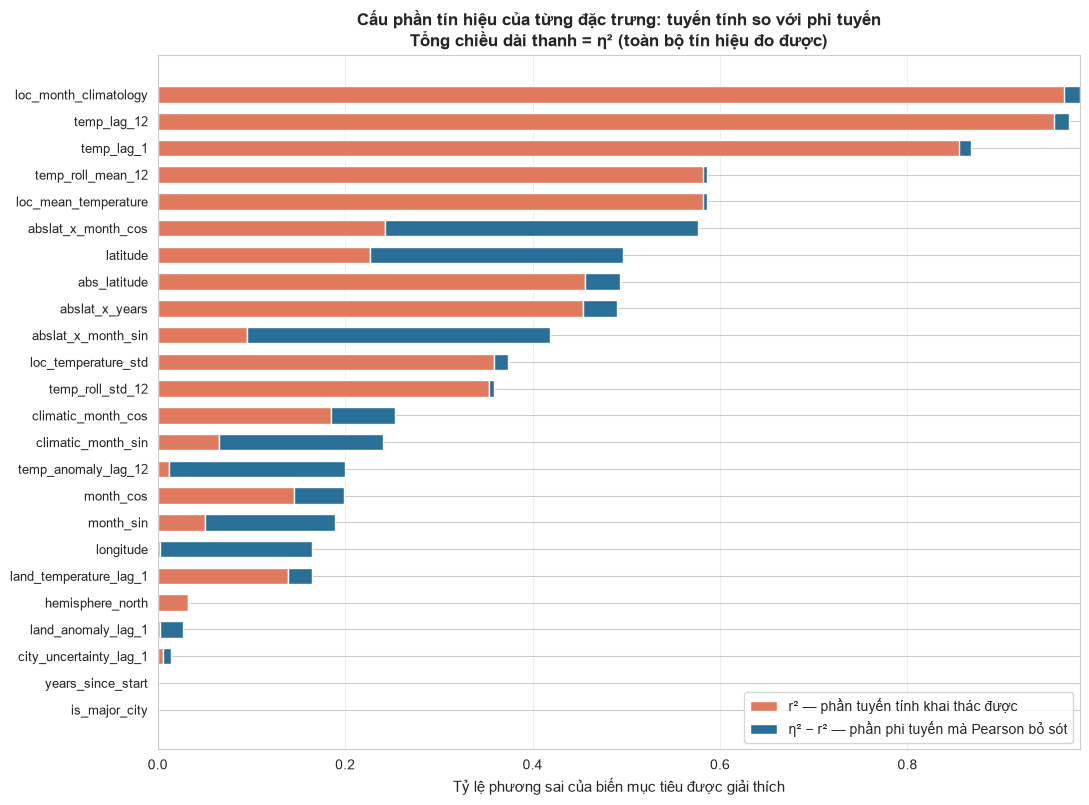

Năm đặc trưng có phần phi tuyến lớn nhất (mô hình tuyến tính khai thác được ít nhất):


,Nhóm,Pearson r,r2,eta2,Phi tuyến (eta2 - r2)
Feature,,,,,
abslat_x_month_cos,Tương tác,-0.4919,0.2420,0.5762,0.3342
abslat_x_month_sin,Tương tác,-0.3085,0.0952,0.4191,0.3239
latitude,Địa lý,-0.4761,0.2266,0.4965,0.2698
temp_anomaly_lag_12,Trễ / Trượt,-0.1092,0.0119,0.2001,0.1882
climatic_month_sin,Thời gian,-0.2567,0.0659,0.2402,0.1744


In [52]:
plot_metrics = feature_metrics.dropna(subset=['eta2']).sort_values('eta2')

fig, ax = plt.subplots(figsize=(11, max(6, len(plot_metrics) * 0.34)))
y_positions = np.arange(len(plot_metrics))

# r² là phần mô hình tuyến tính khai thác được; phần còn lại tới η² là phi tuyến.
ax.barh(y_positions, plot_metrics['r2'], height=0.62,
        color='#e07a5f', label='r² — phần tuyến tính khai thác được')
ax.barh(y_positions, plot_metrics['eta2'] - plot_metrics['r2'], height=0.62,
        left=plot_metrics['r2'], color='#2a6f97',
        label='η² − r² — phần phi tuyến mà Pearson bỏ sót')

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_metrics.index, fontsize=9)
ax.set_xlabel('Tỷ lệ phương sai của biến mục tiêu được giải thích', fontsize=11)
ax.set_title('Cấu phần tín hiệu của từng đặc trưng: tuyến tính so với phi tuyến\n'
             'Tổng chiều dài thanh = η² (toàn bộ tín hiệu đo được)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '08_feature_signal_comparison.png', dpi=200,
            bbox_inches='tight')
print('Đã lưu: reports/images/08_feature_signal_comparison.png')
plt.show()

print('Năm đặc trưng có phần phi tuyến lớn nhất '
      '(mô hình tuyến tính khai thác được ít nhất):')
display(
    feature_metrics.nlargest(5, 'Phi tuyến (eta2 - r2)')[
        ['Nhóm', 'Pearson r', 'r2', 'eta2', 'Phi tuyến (eta2 - r2)']
    ]
)

Mỗi thanh trên biểu đồ được chia thành hai phần: phần cam là `r²` — lượng tín hiệu mà một mô hình tuyến tính khai thác được; phần xanh là `η² − r²` — lượng tín hiệu chỉ mô hình phi tuyến mới lấy được.

Đây là kết luận có ý nghĩa trực tiếp cho Notebook 06: nếu phần xanh chiếm tỷ trọng lớn ở nhiều đặc trưng quan trọng, thì hồi quy tuyến tính (Linear Regression, Ridge, Lasso) sẽ **thua rõ rệt** so với các mô hình dạng cây (Decision Tree, Random Forest, Gradient Boosting) — và đó là điều cần được kiểm chứng bằng số liệu ở Notebook 06 thay vì phỏng đoán trước.

### 6.3. Feature Importance

Tương quan chỉ đo liên hệ của **từng** đặc trưng với target một cách riêng lẻ. Feature importance đo mức đóng góp của đặc trưng khi **các đặc trưng khác cùng có mặt**, nên phát hiện được trường hợp một đặc trưng mạnh nhưng chỉ lặp lại thông tin của đặc trưng khác.

Notebook dùng Random Forest trên một mẫu nhỏ. `scikit-learn` là phụ thuộc tùy chọn: nếu chưa cài, cell in hướng dẫn cài đặt và bỏ qua, phần đánh giá vẫn đầy đủ nhờ η² ở Mục 6.2 — notebook không bị dừng giữa dòng.

#### 6.3.1. Kiểm tra thư viện

Feature importance là phân tích bổ sung; notebook vẫn hoàn thành nếu thiếu scikit-learn.


In [53]:
IMPORTANCE_SAMPLE_ROWS = 120_000
feature_importance = None

try:
    from sklearn.ensemble import RandomForestRegressor
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

if not HAS_SKLEARN:
    print('Bỏ qua Feature Importance vì chưa cài scikit-learn.')


#### 6.3.2. Huấn luyện mô hình thăm dò

Random Forest chỉ fit trên mẫu validation đủ giá trị và không được xem là model chính thức.


In [54]:
if HAS_SKLEARN:
    dense_df = eval_df[CANDIDATE_FEATURES + [TARGET_COLUMN]].dropna()
    if len(dense_df) > IMPORTANCE_SAMPLE_ROWS:
        dense_df = dense_df.sample(IMPORTANCE_SAMPLE_ROWS, random_state=RANDOM_SEED)

    forest = RandomForestRegressor(
        n_estimators=60, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=RANDOM_SEED,
    )
    forest.fit(dense_df[CANDIDATE_FEATURES], dense_df[TARGET_COLUMN])
    feature_importance = pd.Series(
        forest.feature_importances_, index=CANDIDATE_FEATURES, name='importance'
    ).sort_values(ascending=False)


#### 6.3.3. Hiển thị mức quan trọng

R² trên chính mẫu fit chỉ để kiểm tra kỹ thuật, không dùng báo cáo hiệu năng mô hình.


Mẫu huấn luyện importance: 120,000 dòng
R² trên chính mẫu này: 0.9930


,importance
loc_month_climatology,0.9927
years_since_start,0.0015
land_anomaly_lag_1,0.0007
temp_lag_1,0.0006
land_temperature_lag_1,0.0006
abslat_x_month_sin,0.0005
temp_roll_mean_12,0.0004
temp_anomaly_lag_12,0.0004
temp_lag_12,0.0004
abslat_x_years,0.0004


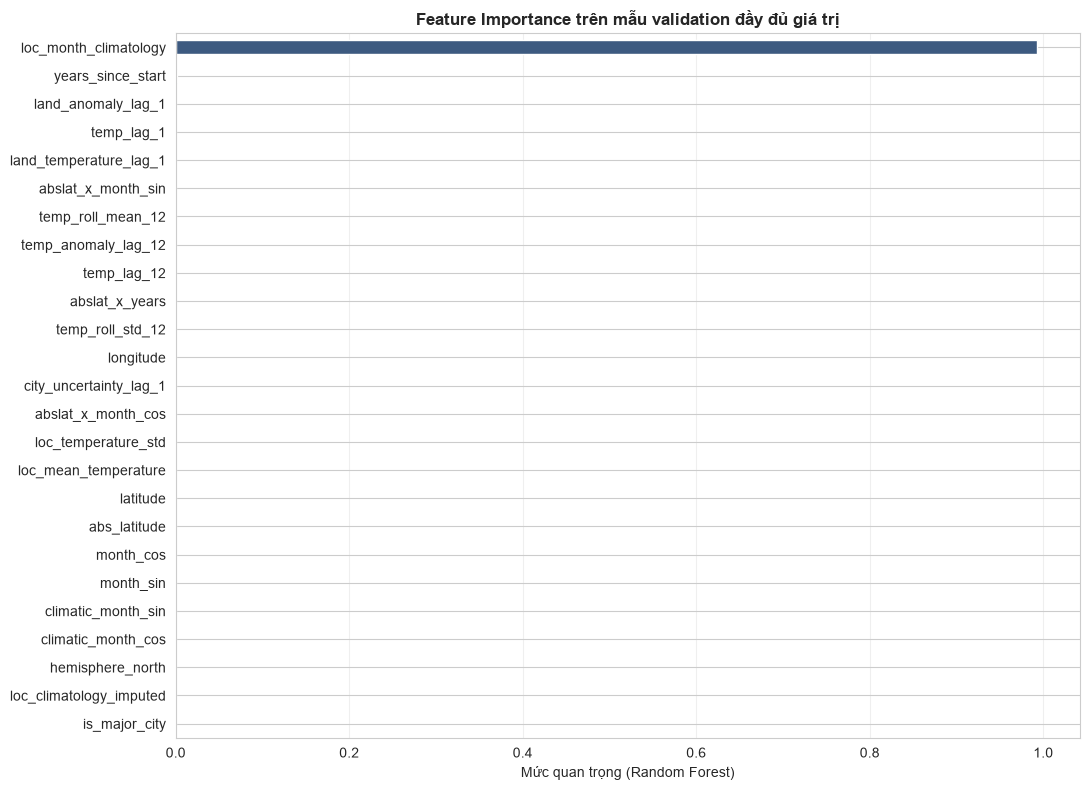

In [55]:
if feature_importance is not None:
    print(f'Mẫu huấn luyện importance: {len(dense_df):,} dòng')
    print(f'R² trên chính mẫu này: {forest.score(dense_df[CANDIDATE_FEATURES], dense_df[TARGET_COLUMN]):.4f}')
    display(feature_importance.to_frame())

    fig, ax = plt.subplots(figsize=(11, max(6, len(feature_importance) * 0.32)))
    feature_importance.sort_values().plot.barh(ax=ax, color='#3d5a80')
    ax.set_xlabel('Mức quan trọng (Random Forest)')
    ax.set_title('Feature Importance trên mẫu validation đầy đủ giá trị', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(REPORT_IMAGES_DIR / '09_feature_importance.png', dpi=200, bbox_inches='tight')
    plt.show()


Nếu cell chạy được, cần lưu ý hai điều khi đọc kết quả. Thứ nhất, `R²` in ra được tính trên chính tập vừa huấn luyện nên luôn lạc quan; đây **không** phải chỉ số đánh giá mô hình — việc đó thuộc Notebook 06 với tập test tách theo thời gian. Thứ hai, importance của Random Forest bị chia đều giữa các đặc trưng trùng lặp thông tin, nên một đặc trưng có importance thấp chưa hẳn vô dụng; cần đọc cùng bảng đa cộng tuyến ở Mục 6.4.

Việc phải bỏ các dòng thiếu giá trị cũng khiến tập này nghiêng về giai đoạn sau của dữ liệu — nơi các đặc trưng trễ đã có đủ quá khứ. Ngoài ra, importance cao không thể vượt qua cổng khả dụng: feature `history` vẫn bị loại khỏi mô hình triển khai nếu backend không thể tái tạo nó cho tháng tương lai.

### 6.4. Kiểm tra đa cộng tuyến giữa các đặc trưng

Quá trình tạo feature có thể sinh ra các cặp gần như trùng thông tin, ví dụ climatology với lag 12 tháng hoặc các thống kê vị trí với rolling statistics. Cell dưới đo tương quan giữa các candidate feature trên validation và chuyển các cặp vượt ngưỡng sang quy tắc lược bỏ ở Mục 7.


In [56]:
correlation_matrix = eval_df[CANDIDATE_FEATURES].corr()

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
redundant_pairs = (
    upper_triangle.stack()
    .rename('Pearson r')
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B'})
)
redundant_pairs['|r|'] = redundant_pairs['Pearson r'].abs()
redundant_pairs = (
    redundant_pairs[redundant_pairs['|r|'] > REDUNDANCY_THRESHOLD]
    .sort_values('|r|', ascending=False)
    .reset_index(drop=True)
)

print(f'Ngưỡng trùng lặp: |r| > {REDUNDANCY_THRESHOLD}')
if redundant_pairs.empty:
    print('Không có cặp đặc trưng nào vượt ngưỡng trùng lặp.')
else:
    print(f'Có {len(redundant_pairs)} cặp vượt ngưỡng:')
    display(redundant_pairs[['Feature A', 'Feature B', 'Pearson r']])

Ngưỡng trùng lặp: |r| > 0.95
Có 4 cặp vượt ngưỡng:


,Feature A,Feature B,Pearson r
0,abs_latitude,abslat_x_years,0.9987
1,loc_mean_temperature,temp_roll_mean_12,0.9978
2,loc_month_climatology,temp_lag_12,0.9920
3,loc_temperature_std,temp_roll_std_12,0.9910


Mỗi cặp xuất hiện ở đây nghĩa là hai đặc trưng gần như mang cùng một thông tin. Giữ cả hai không làm mô hình chính xác hơn nhưng làm hệ số của mô hình tuyến tính mất ổn định và làm importance của mô hình cây bị chia nhỏ. Mục 7 sẽ giữ lại đặc trưng có `eta2` cao hơn trong mỗi cặp.

### 6.5. Kiểm tra rò rỉ dữ liệu

Mục này thực hiện ba nhóm kiểm tra:

1. Đo lại mức tương quan của các cột nhiệt độ cùng tháng bị loại.
2. Xác minh `temp_lag_12` đúng là target của cùng vị trí tại `t − 12`.
3. Xác minh candidate feature không chứa dữ liệu cùng kỳ/target-derived và mẫu chọn feature chỉ thuộc validation, không chứa test.


In [57]:
# --- Phép thử 1: mức tương quan của các cột bị loại --------------------
leakage_candidates = ['major_city_average_temperature', 'country_average_temperature']
leakage_rows = []
for column in leakage_candidates:
    valid = eval_df[column].notna() & eval_target.notna()
    leakage_rows.append(
        {
            'Cột nguồn': column,
            'Số dòng có giá trị': int(valid.sum()),
            'Tỷ lệ có giá trị': float(valid.mean()),
            'Pearson r với target': float(eval_df.loc[valid, column].corr(eval_target[valid]))
            if valid.sum() > 1 else float('nan'),
        }
    )
display(pd.DataFrame(leakage_rows).set_index('Cột nguồn'))
print('→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố '
      'đang dự báo, nên không được dùng làm đặc trưng.')

,Số dòng có giá trị,Tỷ lệ có giá trị,Pearson r với target
Cột nguồn,,,
major_city_average_temperature,10200,0.0273,1.0000
country_average_temperature,374280,1.0000,0.8983


→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố đang dự báo, nên không được dùng làm đặc trưng.


In [58]:
# --- Phép thử 2: temp_lag_12 phải khớp target của 12 tháng trước -------
check_frame = feature_df[['location_key', TARGET_COLUMN, 'temp_lag_12']]
verify_pool = check_frame[check_frame['temp_lag_12'].notna()]
verify_size = min(5_000, len(verify_pool))
verify_sample = verify_pool.sample(n=verify_size, random_state=RANDOM_SEED)

truth_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(), index=feature_df['location_key'].to_numpy()
)
expected_lag = truth_lookup.reindex(verify_sample['location_key'].to_numpy() - 12).to_numpy()
lag_matches = np.allclose(
    verify_sample['temp_lag_12'].to_numpy(dtype='float64'),
    expected_lag.astype('float64'),
    equal_nan=True,
)

print(f'Kiểm tra {verify_size:,} dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước '
      f'→ {"PASS" if lag_matches else "FAIL"}')
if not lag_matches:
    raise RuntimeError('temp_lag_12 không khớp giá trị quá khứ; đặc trưng trễ bị sai mốc.')

# Không đặc trưng trễ nào được trùng chính target của cùng tháng.
same_month_leak = [
    name for name in ('temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12')
    if np.isclose(
        feature_df[name].corr(feature_df[TARGET_COLUMN]), 1.0, atol=1e-6
    )
]
print(f'Đặc trưng trễ trùng khớp target: {same_month_leak or "không có"}')

Kiểm tra 5,000 dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước → PASS
Đặc trưng trễ trùng khớp target: không có


In [59]:
# --- Phép thử 3: không feature nào trùng target hoặc dùng dữ liệu cùng kỳ ---
LEAKAGE_CORRELATION_LIMIT = 0.999
suspicious = feature_metrics[feature_metrics['|Pearson|'] > LEAKAGE_CORRELATION_LIMIT]
if not suspicious.empty:
    display(suspicious)
    raise RuntimeError('Có feature gần như trùng khớp hoàn toàn với target.')

forbidden_same_month_features = {
    'major_city_average_temperature',
    'country_average_temperature',
    'land_average_temperature',
    'city_average_temperature_uncertainty',
    'temp_anomaly_vs_climatology',
}
forbidden_candidates = forbidden_same_month_features.intersection(CANDIDATE_FEATURES)
if forbidden_candidates:
    raise RuntimeError(
        f'Candidate feature chứa dữ liệu cùng kỳ/target-derived: {forbidden_candidates}'
    )

if not eval_df['year'].between(VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR).all():
    raise RuntimeError('Mẫu chọn feature không thuần validation theo thời gian.')
if (eval_df['year'] > TRAIN_CUTOFF_YEAR).any():
    raise RuntimeError('Dữ liệu test đã lọt vào bước chọn feature.')

print(f'PASS: không feature nào có |r| > {LEAKAGE_CORRELATION_LIMIT}.')
print('PASS: không có dữ liệu cùng kỳ hoặc feature suy ra trực tiếp từ target.')
print('PASS: đánh giá/chọn feature chỉ dùng giai đoạn validation, không dùng test.')


PASS: không feature nào có |r| > 0.999.
PASS: không có dữ liệu cùng kỳ hoặc feature suy ra trực tiếp từ target.
PASS: đánh giá/chọn feature chỉ dùng giai đoạn validation, không dùng test.


Các dòng `PASS` xác nhận những điều kiện leakage mà notebook có thể kiểm tra tự động. Chúng không thay thế việc định nghĩa đúng kịch bản dự báo; vì vậy metadata vẫn ghi rõ `forecast_scenario` và `availability` để Notebook 06/07 tuân thủ.


### 6.6. SHAP (nâng cao, tùy chọn)

SHAP phân bổ phần đóng góp của từng đặc trưng vào **từng dự báo cụ thể**, thay vì chỉ đưa ra một con số quan trọng chung cho toàn mô hình. Nhờ đó có thể trả lời những câu hỏi như: với một thành phố ở vĩ độ cao vào tháng 1, đặc trưng nào đã kéo dự báo xuống thấp.

Đây là phần nâng cao và `shap` không nằm trong `requirements.txt`, nên cell dưới chỉ chạy khi thư viện đã được cài; nếu không, notebook bỏ qua và đi tiếp.

In [60]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

if not (HAS_SHAP and HAS_SKLEARN and feature_importance is not None):
    print('Bỏ qua SHAP (cần cả shap và scikit-learn).')
    print('Nếu muốn dùng:  python -m pip install shap')
else:
    shap_sample = dense_df.sample(n=min(2_000, len(dense_df)), random_state=RANDOM_SEED)
    explainer = shap.TreeExplainer(forest)
    shap_values = explainer.shap_values(shap_sample[CANDIDATE_FEATURES], check_additivity=False)
    mean_abs_shap = (
        pd.Series(np.abs(shap_values).mean(axis=0), index=CANDIDATE_FEATURES,
                  name='mean |SHAP| (°C)')
        .sort_values(ascending=False)
    )
    display(mean_abs_shap.to_frame())
    print('Giá trị đọc là: trung bình mức dịch chuyển dự báo (°C) do đặc trưng đó gây ra.')

,mean |SHAP| (°C)
loc_month_climatology,7.8354
years_since_start,0.1077
temp_lag_1,0.0805
land_anomaly_lag_1,0.0703
temp_roll_mean_12,0.0405
abslat_x_month_sin,0.0405
land_temperature_lag_1,0.0384
temp_lag_12,0.0301
temp_anomaly_lag_12,0.0224
temp_roll_std_12,0.0224


Giá trị đọc là: trung bình mức dịch chuyển dự báo (°C) do đặc trưng đó gây ra.


## 7. Lựa chọn Feature

### 7.1. Bộ quy tắc lựa chọn

Bộ quy tắc được áp dụng theo thứ tự sau:

| Thứ tự | Kiểm tra | Kết quả |
|---:|---|---|
| 1 | `availability` không thuộc `static` hoặc `fit_stat` | Loại |
| 2 | Feature thuộc cặp chu kỳ hoặc xu hướng bắt buộc | Giữ |
| 3 | Feature hằng số | Loại |
| 4 | Đồng thời `η² < 0.005` và `|Pearson| < 0.05` | Loại |
| 5 | Hai feature có `|r| > 0.95` | Loại feature có `η²` thấp hơn |

Test 1994–2013 không tham gia bất kỳ quyết định chọn feature nào.


#### 7.1.1. Áp dụng availability và ngưỡng tín hiệu

Hàm trả về một quyết định cùng lý do ngắn cho từng feature.


In [61]:
def initial_feature_decision(name: str) -> dict:
    meta = FEATURE_CATALOG[name]
    if meta['availability'] not in DEPLOYMENT_ALLOWED_AVAILABILITY:
        return {'decision': 'Loại', 'reason': f"Không khả dụng khi dự báo: {meta['availability']}."}
    if meta['force_keep']:
        return {'decision': 'Giữ', 'reason': f"Giữ bắt buộc. {meta['keep_reason']}"}
    if eval_df[name].nunique(dropna=True) < 2:
        return {'decision': 'Loại', 'reason': 'Cột hằng số, không có khả năng phân biệt.'}

    eta = feature_metrics.loc[name, 'eta2']
    abs_pearson = feature_metrics.loc[name, '|Pearson|']
    weak_eta = pd.isna(eta) or eta < MIN_ETA_SQUARED
    weak_pearson = pd.isna(abs_pearson) or abs_pearson < MIN_ABS_PEARSON
    if weak_eta and weak_pearson:
        return {
            'decision': 'Loại',
            'reason': f'Tín hiệu yếu: η²={eta:.4f}, |r|={abs_pearson:.4f}.',
        }
    return {'decision': 'Giữ', 'reason': 'Đạt ngưỡng tín hiệu và khả dụng khi dự báo.'}


selection_records = {
    name: initial_feature_decision(name) for name in CANDIDATE_FEATURES
}


#### 7.1.2. Loại feature trùng lặp

Trong mỗi cặp vượt ngưỡng tương quan, giữ feature có η² cao hơn.


In [62]:
for _, pair in redundant_pairs.iterrows():
    first, second = pair['Feature A'], pair['Feature B']
    if selection_records[first]['decision'] == 'Loại' or selection_records[second]['decision'] == 'Loại':
        continue

    first_eta = feature_metrics.loc[first, 'eta2']
    second_eta = feature_metrics.loc[second, 'eta2']
    weaker, stronger = (first, second) if second_eta > first_eta else (second, first)
    if FEATURE_CATALOG[weaker]['force_keep']:
        continue
    selection_records[weaker] = {
        'decision': 'Loại',
        'reason': f'Trùng {stronger} (r={pair["Pearson r"]:.4f}); η² thấp hơn.',
    }


#### 7.1.3. Chốt danh sách

Danh sách cuối phải chỉ gồm feature `static` hoặc `fit_stat`.


In [63]:
SELECTED_FEATURES = [
    name for name in CANDIDATE_FEATURES
    if selection_records[name]['decision'] == 'Giữ'
]
DROPPED_FEATURES = [
    name for name in CANDIDATE_FEATURES
    if selection_records[name]['decision'] == 'Loại'
]

non_deployable = [
    name for name in SELECTED_FEATURES
    if FEATURE_CATALOG[name]['availability'] not in DEPLOYMENT_ALLOWED_AVAILABILITY
]
if non_deployable:
    raise RuntimeError(f'Feature cuối không khả dụng: {non_deployable}')

print(f'Ứng viên: {len(CANDIDATE_FEATURES)} · Giữ: {len(SELECTED_FEATURES)} · Loại: {len(DROPPED_FEATURES)}')
print('Feature không phụ thuộc quan sát tại/sau tháng mục tiêu: PASS')


Ứng viên: 25 · Giữ: 14 · Loại: 11
Feature không phụ thuộc quan sát tại/sau tháng mục tiêu: PASS


### 7.2. Bảng quyết định giữ / loại

#### 7.2.1. Quyết định cho feature số

Bảng ghép tín hiệu validation với quyết định và lý do giữ/loại.


In [64]:
from pandas import set_option


decision_table = feature_metrics.join(
    pd.DataFrame(
        [
            {
                'Feature': name,
                'Khả dụng': FEATURE_CATALOG[name]['availability'],
                'Kết quả': selection_records[name]['decision'],
                'Lý do': selection_records[name]['reason'],
            }
            for name in CANDIDATE_FEATURES
        ]
    ).set_index('Feature')
)
decision_table = decision_table[
    ['Nhóm', 'Khả dụng', 'Pearson r', 'r2', 'Spearman', 'eta2', 'Kết quả', 'Lý do']
].sort_values(['Kết quả', 'eta2'], ascending=[True, False])

# hiển thị đầy đủ bảng, do kích thước lớn nên không hiển thị hết trong notebook
set_option('display.max_rows', None)

display(decision_table)
display(
    decision_table.groupby(['Nhóm', 'Kết quả'], observed=True)
    .size()
    .unstack(fill_value=0)
)


,Nhóm,Khả dụng,Pearson r,r2,Spearman,eta2,Kết quả,Lý do
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,fit_stat,0.9920,0.9841,0.9934,0.9665,Giữ,Đạt ngưỡng tín hiệu và khả dụng khi dự báo.
loc_mean_temperature,Khí hậu theo vị trí,fit_stat,0.7655,0.5859,0.7927,0.5816,Giữ,Đạt ngưỡng tín hiệu và khả dụng khi dự báo.
abslat_x_month_cos,Tương tác,static,-0.4919,0.2420,-0.4194,0.5762,Giữ,Đạt ngưỡng tín hiệu và khả dụng khi dự báo.
latitude,Địa lý,static,-0.4761,0.2266,-0.5925,0.4965,Giữ,Đạt ngưỡng tín hiệu và khả dụng khi dự báo.
abs_latitude,Địa lý,static,-0.6751,0.4557,-0.7098,0.4928,Giữ,Đạt ngưỡng tín hiệu và khả dụng khi dự báo.
abslat_x_month_sin,Tương tác,static,-0.3085,0.0952,-0.2838,0.4191,Giữ,Đạt ngưỡng tín hiệu và khả dụng khi dự báo.
loc_temperature_std,Khí hậu theo vị trí,fit_stat,-0.5989,0.3587,-0.5792,0.3734,Giữ,Đạt ngưỡng tín hiệu và khả dụng khi dự báo.
climatic_month_cos,Thời gian,static,-0.4303,0.1851,-0.3845,0.2531,Giữ,Giữ bắt buộc. Thành phần của cặp mã hóa tuần h...
climatic_month_sin,Thời gian,static,-0.2567,0.0659,-0.2549,0.2402,Giữ,Giữ bắt buộc. Thành phần của cặp mã hóa tuần h...


Kết quả,Giữ,Loại
Nhóm,,
Bối cảnh toàn cầu,0,2
Chất lượng dữ liệu,0,1
Khí hậu theo vị trí,3,1
Thời gian,5,0
Trễ / Trượt,0,5
Tương tác,2,1
Địa lý,4,1


#### 7.2.2. Quyết định cho `country_name`

Country được giữ và one-hot trong Pipeline của Notebook 06.


In [65]:
country_decision = country_metric.copy()
country_decision['Khả dụng'] = 'static'
country_decision['Kết quả'] = 'Giữ'
country_decision['Lý do'] = (
    'Biết trước từ thành phố; mã hóa one-hot trong Pipeline để bổ sung tín hiệu vùng.'
)
display(country_decision)


,Số nhóm,eta2,Cách xử lý,Khả dụng,Kết quả,Lý do
country_name,50,0.4873,OneHotEncoder(handle_unknown='ignore'),static,Giữ,Biết trước từ thành phố; mã hóa one-hot trong ...


Bảng này là sản phẩm chính của Mục 7. Cần đọc `Kết quả` cùng `Khả dụng`: các feature lịch sử có thể đạt tín hiệu cao nhưng vẫn bị loại vì không thể tạo khi người dùng chọn tháng tương lai. Đây là quyết định theo data contract triển khai, không phải kết luận rằng lag feature vô ích về mặt thống kê.

### 7.3. Các cột bị loại vì ngữ nghĩa hoặc không khả dụng khi triển khai

Ngoài các feature ứng viên, những cột sau bị loại theo ngữ nghĩa:

| Cột / nhóm cột | Lý do loại |
|---|---|
| `major_city_average_temperature` | Phép đo cùng tháng, có thể trùng trực tiếp với target |
| `country_average_temperature` | Nhiệt độ quốc gia cùng tháng đã chứa thông tin của thành phố |
| `land_average_temperature` cùng tháng | Chưa biết tại thời điểm dự báo tương lai |
| `city_average_temperature_uncertainty` cùng tháng | Chỉ xuất hiện khi target đã được đo |
| Các cột land max/min/ocean cùng tháng | Không biết trước tại forecast origin |
| Lag/rolling nhiệt độ, land và uncertainty | Nguồn dự án không cập nhật sau 2013 nên backend không tạo được |
| `month`, `quarter`, `decade` dạng thô | Đã thay bằng sin/cos và xu hướng năm |
| `city_temperature_iqr_outlier` | Cờ kiểm tra chất lượng, không phải đầu vào dự báo |
| `latitude_zone`, `climatic_season` | Chỉ dùng phân tích; thông tin đã có trong feature liên tục |
| `temp_anomaly_vs_climatology` | Suy ra trực tiếp từ target, chỉ dùng tạo insight |


#### 7.3.1. Khai báo loại trừ cho metadata

Dictionary dưới được ghi vào metadata; bảng Markdown phía trên là phần trình bày cho người đọc.


In [66]:
SEMANTIC_EXCLUSIONS = {
    'major_city_average_temperature': 'Phép đo cùng tháng, có thể trùng target.',
    'country_average_temperature': 'Nhiệt độ quốc gia cùng tháng chứa thông tin thành phố.',
    'land_average_temperature (cùng tháng)': 'Không biết trước khi dự báo tương lai.',
    'city_average_temperature_uncertainty (cùng tháng)': 'Chỉ có khi target đã được đo.',
    'land max/min/ocean cùng tháng': 'Không biết trước tại forecast origin.',
    'temp/land/uncertainty lag và rolling': 'Không khả dụng vì nguồn dừng ở 2013.',
    'month / quarter / decade dạng thô': 'Đã biểu diễn bằng sin/cos và xu hướng.',
    'city_temperature_iqr_outlier': 'Cờ chất lượng, không phải đầu vào dự báo.',
    'latitude_zone / climatic_season': 'Chỉ dùng phân tích.',
    'temp_anomaly_vs_climatology': 'Suy ra từ target, chỉ dùng tạo insight.',
}

print('Feature số cuối cùng:')
for index, name in enumerate(SELECTED_FEATURES, start=1):
    print(f'{index:2d}. {name}')
print('Feature phân loại:', CATEGORICAL_FEATURES)


Feature số cuối cùng:
 1. month_sin
 2. month_cos
 3. climatic_month_sin
 4. climatic_month_cos
 5. years_since_start
 6. latitude
 7. abs_latitude
 8. hemisphere_north
 9. longitude
10. abslat_x_month_sin
11. abslat_x_month_cos
12. loc_month_climatology
13. loc_mean_temperature
14. loc_temperature_std
Feature phân loại: ['country_name']


Danh sách in ra chính là thứ tự đặc trưng sẽ được ghi vào `feature_metadata.json` ở Mục 9.3. Notebook 06 phải đọc đúng danh sách và đúng thứ tự này, vì mô hình sau khi huấn luyện chỉ nhận đầu vào theo một thứ tự cột cố định.

## 8. Insight mới từ tập đặc trưng

Tập đặc trưng vừa xây dựng cho phép trả lời những câu hỏi mà Notebook 04 chưa trả lời được. Mục này khai thác `temp_anomaly_vs_climatology` — phần nhiệt độ lệch khỏi mức bình thường của chính thành phố đó trong tháng đó.

Cột này **không được dùng làm đặc trưng** vì nó suy ra trực tiếp từ target. Nhưng chính vì thế nó là công cụ phân tích tốt: nó đã loại bỏ hoàn toàn ảnh hưởng của mùa vụ và của vị trí, nên phần còn lại chủ yếu là tín hiệu biến đổi khí hậu.

### 8.1. Tính anomaly theo vành đai và năm

Anomaly chỉ dùng cho insight, không đi vào bảng feature cuối.


In [67]:
feature_df['temp_anomaly_vs_climatology'] = (
    feature_df[TARGET_COLUMN] - feature_df['loc_month_climatology']
).astype('float32')

anomaly_by_zone_year = (
    feature_df.groupby(['latitude_zone', 'year'], observed=True)[
        'temp_anomaly_vs_climatology'
    ]
    .mean()
    .reset_index()
)


### 8.2. Trực quan hóa anomaly dài hạn

Trung bình trượt 10 năm làm rõ xu hướng và giảm nhiễu năm đơn lẻ.


Đã lưu: reports/images/10_anomaly_by_latitude_zone.png


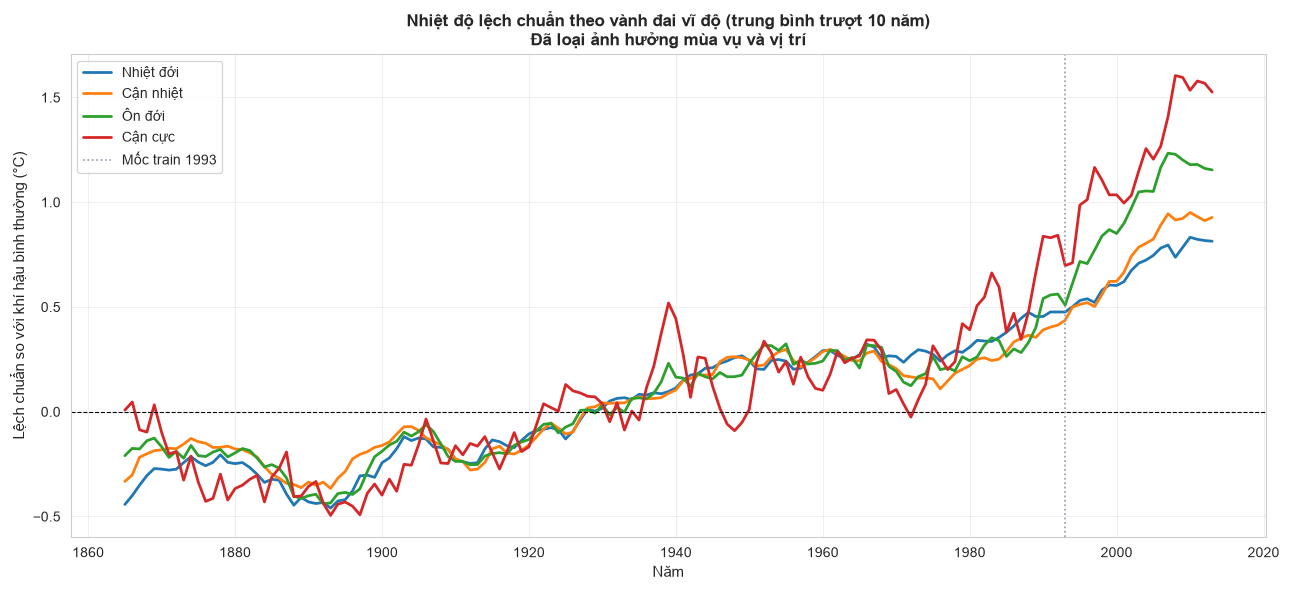

In [68]:
fig, ax = plt.subplots(figsize=(13, 6))
for zone, zone_data in anomaly_by_zone_year.groupby('latitude_zone', observed=True):
    smoothed = zone_data.set_index('year')['temp_anomaly_vs_climatology'].rolling(
        10, min_periods=3
    ).mean()
    ax.plot(smoothed.index, smoothed.to_numpy(), linewidth=2, label=str(zone))

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(TRAIN_CUTOFF_YEAR, color='#8d99ae', linewidth=1.2, linestyle=':',
           label=f'Mốc train {TRAIN_CUTOFF_YEAR}')
ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('Lệch chuẩn so với khí hậu bình thường (°C)', fontsize=11)
ax.set_title('Nhiệt độ lệch chuẩn theo vành đai vĩ độ (trung bình trượt 10 năm)\n'
             'Đã loại ảnh hưởng mùa vụ và vị trí',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '10_anomaly_by_latitude_zone.png', dpi=200,
            bbox_inches='tight')
print('Đã lưu: reports/images/10_anomaly_by_latitude_zone.png')
plt.show()


### 8.3. Hàm ước lượng tốc độ thay đổi

Độ dốc được tính bằng hồi quy tuyến tính trên anomaly trung bình năm.


In [69]:
def warming_rate(group: pd.DataFrame) -> float:
    """Độ dốc °C/năm của anomaly trung bình theo năm."""
    if len(group) < 10:
        return float('nan')
    slope, _ = np.polyfit(
        group['year'].to_numpy(dtype='float64'),
        group['temp_anomaly_vs_climatology'].to_numpy(dtype='float64'),
        1,
    )
    return float(slope)


### 8.4. So sánh tốc độ theo vành đai

Bảng giúp nhận biết xu hướng khác nhau theo vị trí, nhưng không được diễn giải là tốc độ nóng lên tuyệt đối toàn cầu.


In [70]:
warming_by_zone = (
    anomaly_by_zone_year.groupby('latitude_zone', observed=True)[
        ['year', 'temp_anomaly_vs_climatology']
    ]
    .apply(warming_rate)
    .sort_values(ascending=False)
    .to_frame('Tốc độ ấm lên (°C/năm)')
    .rename_axis('Vành đai vĩ độ')
)
warming_by_zone['Trên 100 năm (°C)'] = warming_by_zone['Tốc độ ấm lên (°C/năm)'] * 100
display(warming_by_zone)

overall_slope = warming_rate(
    feature_df.groupby('year', observed=True)['temp_anomaly_vs_climatology']
    .mean()
    .reset_index()
)
print(f'Tốc độ anomaly toàn tập: {overall_slope:.4f}°C/năm')
print('Notebook 04 ghi nhận mức thay đổi nhiệt độ thô xấp xỉ +0,027°C/năm; '
      'năm 2013 chỉ có dữ liệu đến tháng 9.')


,Tốc độ ấm lên (°C/năm),Trên 100 năm (°C)
Vành đai vĩ độ,,
Cận cực,0.0113,1.1256
Ôn đới,0.0091,0.9108
Nhiệt đới,0.0080,0.8038
Cận nhiệt,0.0075,0.7536


Tốc độ anomaly toàn tập: 0.0083°C/năm
Notebook 04 ghi nhận mức thay đổi nhiệt độ thô xấp xỉ +0,027°C/năm; năm 2013 chỉ có dữ liệu đến tháng 9.


Mục 8 chỉ tạo insight sau khi danh sách feature đã được chốt; `temp_anomaly_vs_climatology` không phải candidate và không xuất sang Notebook 06. Kết quả theo vĩ độ bổ sung góc nhìn về xu hướng sau khi đã điều chỉnh nền khí hậu theo vị trí. Khi diễn giải vẫn cần lưu ý năm 2013 chỉ có dữ liệu đến tháng 9.


## 9. Lưu dữ liệu mới

### 9.1. Chuẩn bị bảng đầu ra

Bảng đầu ra gồm khóa nghiệp vụ, `year`/`month`, target, feature future-known đã chọn và nhãn `data_split`. `country_name` vừa thuộc khóa vừa là biến phân loại; Notebook 06 phải one-hot trong Pipeline thay vì mã hóa số thứ tự.

Không lưu lag/rolling, feature bối cảnh cần cập nhật, cột suy ra từ target, phép đo cùng tháng hoặc khóa kỹ thuật tạm. `data_split` có ba giá trị `train`, `validation`, `test`; Notebook 06 phải dùng nhãn này thay vì chia ngẫu nhiên. `is_train_period` được giữ để tương thích và bằng 1 cho train + validation.


#### 9.1.1. Gán nhãn train–validation–test

Nhãn được tạo từ các mask thời gian đã kiểm tra ở Mục 4.3.


In [71]:
OUTPUT_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
    'year', 'month',
]

feature_df['data_split'] = np.select(
    [feature_fit_mask, validation_period_mask, test_period_mask],
    ['train', 'validation', 'test'],
    default='unassigned',
)
feature_df['is_train_period'] = train_period_mask.astype('int8')

MODEL_INPUT_COLUMNS = SELECTED_FEATURES + CATEGORICAL_FEATURES


#### 9.1.2. Tạo DataFrame bàn giao

Đầu ra gồm khóa, target, 14 feature số, `country_name` và nhãn split.


In [72]:
output_columns = (
    OUTPUT_KEY_COLUMNS
    + [TARGET_COLUMN]
    + [name for name in SELECTED_FEATURES if name not in OUTPUT_KEY_COLUMNS]
    + ['data_split', 'is_train_period']
)
output_df = feature_df[output_columns]


#### 9.1.3. Kiểm tra leakage trong đầu ra

Bất kỳ cột cùng tháng hoặc feature history nào xuất hiện sẽ làm notebook dừng.


In [73]:
forbidden_output_columns = {
    'temp_anomaly_vs_climatology',
    'major_city_average_temperature',
    'country_average_temperature',
    'land_average_temperature',
    'city_average_temperature_uncertainty',
    'temp_lag_1',
    'temp_lag_12',
    'temp_roll_mean_12',
    'temp_roll_std_12',
    'temp_anomaly_lag_12',
    'land_temperature_lag_1',
    'land_anomaly_lag_1',
    'city_uncertainty_lag_1',
}
leaked = forbidden_output_columns.intersection(output_df.columns)
if leaked:
    raise RuntimeError(f'Bảng đầu ra chứa cột không hợp lệ: {sorted(leaked)}')
if (feature_df['data_split'] == 'unassigned').any():
    raise RuntimeError('Có dòng chưa được gán data_split.')

print(f'Bảng đầu ra: {len(output_df):,} dòng × {output_df.shape[1]} cột')
print(f'Bộ nhớ      : {output_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
display(output_df.head())
display(output_df['data_split'].value_counts().to_frame('Số dòng'))

missing_model_inputs = set(MODEL_INPUT_COLUMNS) - set(output_df.columns)
if missing_model_inputs:
    raise RuntimeError(f'Bảng đầu ra thiếu đầu vào mô hình: {sorted(missing_model_inputs)}')

print('PASS: bảng đầu ra chỉ chứa feature tái tạo được cho tháng tương lai.')
print('Đầu vào số       :', SELECTED_FEATURES)
print('Đầu vào phân loại:', CATEGORICAL_FEATURES)


Bảng đầu ra: 5,579,085 dòng × 22 cột
Bộ nhớ      : 594.5 MB


,observation_date,city_name,country_name,latitude,longitude,year,month,city_average_temperature,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,abs_latitude,hemisphere_north,abslat_x_month_sin,abslat_x_month_cos,loc_month_climatology,loc_mean_temperature,loc_temperature_std,data_split,is_train_period
0,1863-01-01,A Coruña,Spain,42.5900,-8.7300,1863,1,8.1310,0.5000,0.8660,0.5000,0.8660,0,42.5900,1,21.2950,36.8840,8.3255,13.1197,3.8492,train,1
1,1863-02-01,A Coruña,Spain,42.5900,-8.7300,1863,2,8.7000,0.8660,0.5000,0.8660,0.5000,0,42.5900,1,36.8840,21.2950,8.9935,13.1193,3.8496,train,1
2,1863-03-01,A Coruña,Spain,42.5900,-8.7300,1863,3,9.9850,1.0000,-0.0000,1.0000,-0.0000,0,42.5900,1,42.5900,-0.0000,10.2029,13.1184,3.8505,train,1
3,1863-04-01,A Coruña,Spain,42.5900,-8.7300,1863,4,12.6010,0.8660,-0.5000,0.8660,-0.5000,0,42.5900,1,36.8840,-21.2950,11.4690,13.1166,3.8514,train,1
4,1863-05-01,A Coruña,Spain,42.5900,-8.7300,1863,5,13.2300,0.5000,-0.8660,0.5000,-0.8660,0,42.5900,1,21.2950,-36.8840,13.7391,13.1162,3.8514,train,1


,Số dòng
data_split,
train,4468327
test,736478
validation,374280


PASS: bảng đầu ra chỉ chứa feature tái tạo được cho tháng tương lai.
Đầu vào số       : ['month_sin', 'month_cos', 'climatic_month_sin', 'climatic_month_cos', 'years_since_start', 'latitude', 'abs_latitude', 'hemisphere_north', 'longitude', 'abslat_x_month_sin', 'abslat_x_month_cos', 'loc_month_climatology', 'loc_mean_temperature', 'loc_temperature_std']
Đầu vào phân loại: ['country_name']


### 9.2. Kiểm tra dung lượng và ghi file

Bảng đầu ra có hơn 5,5 triệu dòng nên vẫn có kích thước lớn; sau khi loại feature `history`, file gzip dự kiến nhỏ hơn phiên bản 19 feature trước. Notebook **ước lượng và kiểm tra dung lượng trống trước khi ghi**, thay vì để thao tác ghi làm đầy ổ đĩa rồi thất bại giữa chừng.

Mặc định `OUTPUT_COMPRESSION = 'gzip'`. `pandas.read_csv()` đọc file `.csv.gz` trong suốt nên Notebook 06 không cần xử lý gì thêm. Nếu cần file `.csv` thô, đặt `OUTPUT_COMPRESSION = None` ở Mục 2.3 — với điều kiện còn đủ chỗ trống.

In [74]:
BYTES_PER_VALUE = 9          # ước lượng độ dài trung bình một giá trị trong CSV
GZIP_RATIO = 0.22            # tỷ lệ nén thực nghiệm với dữ liệu dạng số

raw_estimate = len(output_df) * output_df.shape[1] * BYTES_PER_VALUE
estimated_bytes = raw_estimate * (GZIP_RATIO if OUTPUT_COMPRESSION == 'gzip' else 1.0)
free_bytes = shutil.disk_usage(PROCESSED_DIR).free

print(f'Ước lượng kích thước file : {estimated_bytes / 1024 ** 3:,.2f} GB '
      f'({OUTPUT_COMPRESSION or "không nén"})')
print(f'Dung lượng trống          : {free_bytes / 1024 ** 3:,.2f} GB')

if free_bytes < estimated_bytes * 1.3:
    raise RuntimeError(
        f'Không đủ dung lượng trống để ghi {OUTPUT_PATH.name} '
        f'(cần ~{estimated_bytes * 1.3 / 1024 ** 3:.2f} GB, còn {free_bytes / 1024 ** 3:.2f} GB).\n'
        'Cách xử lý: đặt OUTPUT_COMPRESSION = "gzip" ở Mục 2.3, '
        'hoặc dọn bớt file lớn trong data/processed/.'
    )
print('PASS: đủ dung lượng để ghi file.')

Ước lượng kích thước file : 0.23 GB (gzip)
Dung lượng trống          : 37.06 GB
PASS: đủ dung lượng để ghi file.


In [75]:
output_df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding='utf-8',
    date_format='%Y-%m-%d',
    float_format='%.4f',
    compression=OUTPUT_COMPRESSION,
)

actual_size_mb = OUTPUT_PATH.stat().st_size / 1024 ** 2
print('Đã lưu:', OUTPUT_PATH)
print(f'Kích thước thực tế: {actual_size_mb:,.1f} MB')

# Đọc lại vài dòng đầu để xác nhận file hợp lệ và đúng thứ tự cột.
verify_df = pd.read_csv(OUTPUT_PATH, nrows=5)
if list(verify_df.columns) != output_columns:
    raise RuntimeError('Thứ tự cột trong file không khớp bảng đầu ra.')
print(f'PASS: đọc lại được {verify_df.shape[1]} cột đúng thứ tự.')
display(verify_df)

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed\feature_engineered_data.csv.gz
Kích thước thực tế: 90.7 MB
PASS: đọc lại được 22 cột đúng thứ tự.


,observation_date,city_name,country_name,latitude,longitude,year,month,city_average_temperature,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,abs_latitude,hemisphere_north,abslat_x_month_sin,abslat_x_month_cos,loc_month_climatology,loc_mean_temperature,loc_temperature_std,data_split,is_train_period
0,1863-01-01,A Coruña,Spain,42.5900,-8.7300,1863,1,8.1310,0.5000,0.8660,0.5000,0.8660,0,42.5900,1,21.2950,36.8840,8.3255,13.1197,3.8492,train,1
1,1863-02-01,A Coruña,Spain,42.5900,-8.7300,1863,2,8.7000,0.8660,0.5000,0.8660,0.5000,0,42.5900,1,36.8840,21.2950,8.9935,13.1193,3.8496,train,1
2,1863-03-01,A Coruña,Spain,42.5900,-8.7300,1863,3,9.9850,1.0000,-0.0000,1.0000,-0.0000,0,42.5900,1,42.5900,-0.0000,10.2029,13.1184,3.8505,train,1
3,1863-04-01,A Coruña,Spain,42.5900,-8.7300,1863,4,12.6010,0.8660,-0.5000,0.8660,-0.5000,0,42.5900,1,36.8840,-21.2950,11.4690,13.1166,3.8514,train,1
4,1863-05-01,A Coruña,Spain,42.5900,-8.7300,1863,5,13.2300,0.5000,-0.8660,0.5000,-0.8660,0,42.5900,1,21.2950,-36.8840,13.7391,13.1162,3.8514,train,1


`float_format='%.4f'` giới hạn 4 chữ số thập phân: dữ liệu nguồn chỉ có 3 chữ số nên không mất thông tin, mà tránh được việc `float32` in ra hàng chục chữ số vô nghĩa và làm file phình lên.

Bước đọc lại 5 dòng đầu là phép kiểm tra rẻ nhưng hiệu quả: nó xác nhận file ghi thành công, giải nén được và giữ đúng thứ tự cột mà Notebook 06 sẽ dựa vào.

### 9.3. Lưu metadata đặc trưng

Metadata là hợp đồng dữ liệu giữa Notebook 05 và Notebook 06. File ghi phạm vi 1–12 tháng, danh sách feature số, feature phân loại, quy tắc one-hot country, ba mốc chia thời gian, điều kiện availability và cảnh báo dữ liệu kết thúc năm 2013.

Trong ma trận đánh giá, climatology luôn được fit chỉ từ giai đoạn feature-fit để validation/test không rò rỉ. Sau khi đánh giá hoàn tất, `feature_statistics.csv.gz` được **refit trên toàn bộ lịch sử** làm reference triển khai; artifact refit này tuyệt đối không được dùng để tính lại metric validation/test.


#### 9.3.1. Tạo bảng tham chiếu vị trí

Reference giữ thông tin tĩnh của mỗi location và dữ liệu cần tổng hợp sau đánh giá.


In [76]:
location_reference = (
    feature_df[
        ['location_id', 'city_name', 'country_name', 'latitude', 'longitude',
         'latitude_zone', 'is_major_city']
    ]
    .drop_duplicates('location_id')
    .copy()
)

deployment_slice = feature_df[
    ['location_id', 'month', 'latitude_zone', TARGET_COLUMN]
].copy()
deployment_slice['_target_squared'] = deployment_slice[TARGET_COLUMN] ** 2


#### 9.3.2. Tính thống kê triển khai

Sau khi đánh giá hoàn tất, thống kê deployment được refit trên toàn bộ lịch sử.


In [77]:
deployment_loc_month_stats = deployment_slice.groupby(
    ['location_id', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])

deployment_location_stats = deployment_slice.groupby('location_id', observed=True).agg(
    count=(TARGET_COLUMN, 'count'),
    total=(TARGET_COLUMN, 'sum'),
    total_sq=('_target_squared', 'sum'),
)
deployment_zone_month_stats = deployment_slice.groupby(
    ['latitude_zone', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])
deployment_global_month_stats = deployment_slice.groupby(
    'month', observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])


#### 9.3.3. Tạo và lưu `feature_statistics`

File này cho phép ứng dụng tái tạo climatology theo thành phố–tháng.


In [78]:
fixed_location_stats = deployment_location_stats.copy()
fixed_location_stats['loc_mean_temperature'] = (
    fixed_location_stats['total'] / fixed_location_stats['count']
)
location_variance = (
    fixed_location_stats['total_sq']
    - fixed_location_stats['total'] ** 2 / fixed_location_stats['count']
) / (fixed_location_stats['count'] - 1)
fixed_location_stats['loc_temperature_std'] = np.sqrt(np.maximum(location_variance, 0))

feature_statistics = (
    deployment_loc_month_stats.assign(
        loc_month_climatology=lambda frame: frame['sum'] / frame['count']
    )
    .reset_index()[['location_id', 'month', 'loc_month_climatology']]
    .merge(location_reference, on='location_id', how='left', validate='many_to_one')
    .merge(
        fixed_location_stats[['loc_mean_temperature', 'loc_temperature_std']].reset_index(),
        on='location_id', how='left', validate='many_to_one',
    )
)
feature_statistics.to_csv(
    FEATURE_STATS_PATH, index=False, encoding='utf-8',
    float_format='%.6f', compression='gzip',
)


#### 9.3.4. Tạo metadata cốt lõi

Metadata ghi nguồn, grain, split, horizon và hợp đồng đầu vào model.


In [79]:
zone_fallback = (
    deployment_zone_month_stats['sum'] / deployment_zone_month_stats['count']
).to_dict()
global_fallback = (
    deployment_global_month_stats['sum'] / deployment_global_month_stats['count']
).to_dict()

feature_metadata = {
    'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'created_by': '05_feature_engineering.ipynb',
    'data_source': DATA_SOURCE,
    'forecast_scenario': 'future_target_date_with_known_features',
    'forecast_horizon_months': int(FORECAST_HORIZON_MONTHS),
    'prediction_semantics': 'Expected monthly mean from calendar, geography, country and climatology.',
    'fast_mode': FAST_MODE,
    'row_count': int(len(output_df)),
    'location_count': int(feature_df['location_id'].nunique()),
    'target': TARGET_COLUMN,
    'feature_fit_cutoff_year': int(FEATURE_FIT_CUTOFF_YEAR),
    'validation_start_year': int(VALIDATION_START_YEAR),
    'train_cutoff_year': int(TRAIN_CUTOFF_YEAR),
    'split_counts': {str(k): int(v) for k, v in output_df['data_split'].value_counts().items()},
    'observation_date_range': [
        str(feature_df['observation_date'].min().date()),
        str(feature_df['observation_date'].max().date()),
    ],
    'last_year_is_partial': True,
    'last_observation_date': '2013-09-01',
    'output_file': OUTPUT_PATH.name,
    'feature_statistics_file': FEATURE_STATS_PATH.name,
    'evaluation_statistics_scope': f'year <= {FEATURE_FIT_CUTOFF_YEAR}',
    'deployment_statistics_scope': 'all observations after final evaluation',
    'deployment_allowed_availability': sorted(DEPLOYMENT_ALLOWED_AVAILABILITY),
    'postgres_table': f'public.{FEATURE_TABLE}',
    'key_columns': OUTPUT_KEY_COLUMNS,
    'feature_names': MODEL_INPUT_COLUMNS,
    'numeric_feature_names': SELECTED_FEATURES,
    'categorical_feature_names': CATEGORICAL_FEATURES,
    'categorical_preprocessing': {
        'country_name': 'OneHotEncoder(handle_unknown=ignore, drop=None)',
    },
}


#### 9.3.5. Bổ sung chi tiết feature

Ghi chỉ số validation, feature bị loại, fallback và chỉ dẫn cho Notebook 06.


In [80]:
feature_metadata['feature_details'] = {
    name: {
        'group': FEATURE_CATALOG[name]['group'],
        'availability': FEATURE_CATALOG[name]['availability'],
        'description': FEATURE_CATALOG[name]['description'],
        'pearson_r_validation': round(float(feature_metrics.loc[name, 'Pearson r']), 6),
        'eta_squared_validation': round(float(feature_metrics.loc[name, 'eta2']), 6),
    }
    for name in SELECTED_FEATURES
}
feature_metadata['feature_details']['country_name'] = {
    'group': 'Phân loại',
    'availability': 'static',
    'description': 'Quốc gia; one-hot trong Pipeline, không áp đặt thứ tự giả.',
    'eta_squared_validation': round(country_eta_squared, 6),
}
feature_metadata['dropped_features'] = {
    name: selection_records[name]['reason'] for name in DROPPED_FEATURES
}
feature_metadata['fallback_statistics'] = {
    'zone_month_climatology': {
        f'{zone}|{int(month)}': round(float(value), 6)
        for (zone, month), value in zone_fallback.items()
    },
    'global_month_climatology': {
        str(int(month)): round(float(value), 6)
        for month, value in global_fallback.items()
    },
}
feature_metadata['semantic_exclusions'] = SEMANTIC_EXCLUSIONS
feature_metadata['selection_rules'] = {
    'evaluation_split': 'validation',
    'min_eta_squared': MIN_ETA_SQUARED,
    'min_abs_pearson': MIN_ABS_PEARSON,
    'redundancy_threshold': REDUNDANCY_THRESHOLD,
}
feature_metadata['notes_for_notebook_06'] = [
    'Fit trên train, chọn model trên validation, báo cáo cuối trên test.',
    'Không dùng test để chọn feature hoặc điều chỉnh preprocessing.',
    'Dùng đúng feature_names và thứ tự được lưu trong metadata.',
    'One-hot country_name bên trong Pipeline; không one-hot city_name.',
    'Không đưa feature availability=history vào model triển khai.',
    'Đánh giá horizon 1–12 tháng bằng rolling-origin backtest.',
    'Năm 2013 chỉ có dữ liệu đến tháng 9.',
]


#### 9.3.6. Lưu và kiểm tra metadata

Số feature in ra phải bằng 15: 14 feature số và `country_name`.


In [81]:
METADATA_PATH.write_text(
    json.dumps(feature_metadata, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

print('Đã lưu:', FEATURE_STATS_PATH)
print(f'Số dòng thống kê: {len(feature_statistics):,}')
print('Đã lưu:', METADATA_PATH)
print(f'Số feature model: {len(feature_metadata["feature_names"])}')
print('Feature contract:', feature_metadata['feature_names'])


Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed\feature_statistics.csv.gz
Số dòng thống kê: 37,428
Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed\feature_metadata.json
Số feature model: 15
Feature contract: ['month_sin', 'month_cos', 'climatic_month_sin', 'climatic_month_cos', 'years_since_start', 'latitude', 'abs_latitude', 'hemisphere_north', 'longitude', 'abslat_x_month_sin', 'abslat_x_month_cos', 'loc_month_climatology', 'loc_mean_temperature', 'loc_temperature_std', 'country_name']


### 9.4. Kiểm tra tái tạo Feature cho một tháng tương lai

Cell dưới tạo một dòng đầu vào cho **tháng chưa tồn tại trong dữ liệu** chỉ từ `location_id`, ngày mục tiêu và bảng reference đã fit. Đây là phép kiểm tra quan trọng để phân biệt dự báo với tra cứu lịch sử: không đọc `city_average_temperature` của ngày mục tiêu và không cần lag/rolling.

Hàm dùng `location_id` để phân biệt an toàn một số tên thành phố–quốc gia có nhiều tọa độ. Giao diện có thể vẫn hiển thị tên thành phố, nhưng backend phải giữ `location_id` tương ứng làm khóa ẩn.

#### 9.4.1. Tra reference theo location–month

Hàm chỉ lấy bảng thống kê đã lưu, không đọc target của ngày tương lai.


In [82]:
def get_location_month_reference(location_id: int, month: int) -> pd.Series:
    reference = feature_statistics[
        feature_statistics['location_id'].eq(location_id)
        & feature_statistics['month'].eq(month)
    ]
    if reference.empty:
        raise ValueError(f'Không có reference cho location_id={location_id}, tháng={month}.')
    return reference.iloc[0]


#### 9.4.2. Tạo giá trị feature

Feature được suy ra từ lịch, vị trí và climatology cố định.


In [83]:
def future_feature_values(reference: pd.Series, target_date: pd.Timestamp) -> dict:
    month, year = target_date.month, target_date.year
    latitude = float(reference['latitude'])
    abs_latitude = abs(latitude)
    north = int(latitude >= 0)
    climatic_month = month if north else ((month + 5) % 12) + 1
    month_angle = TWO_PI_OVER_12 * month
    climate_angle = TWO_PI_OVER_12 * climatic_month

    return {
        'month_sin': np.sin(month_angle),
        'month_cos': np.cos(month_angle),
        'climatic_month_sin': np.sin(climate_angle),
        'climatic_month_cos': np.cos(climate_angle),
        'years_since_start': year - start_year,
        'latitude': latitude,
        'abs_latitude': abs_latitude,
        'hemisphere_north': north,
        'longitude': float(reference['longitude']),
        'abslat_x_month_sin': abs_latitude * np.sin(climate_angle),
        'abslat_x_month_cos': abs_latitude * np.cos(climate_angle),
        'loc_month_climatology': float(reference['loc_month_climatology']),
        'loc_mean_temperature': float(reference['loc_mean_temperature']),
        'loc_temperature_std': float(reference['loc_temperature_std']),
        'country_name': str(reference['country_name']),
    }


#### 9.4.3. Đóng gói đúng feature contract

DataFrame được sắp đúng thứ tự `MODEL_INPUT_COLUMNS`.


In [84]:
def build_future_known_features(location_id: int, target_date) -> pd.DataFrame:
    target_date = pd.Timestamp(target_date).to_period('M').to_timestamp()
    reference = get_location_month_reference(location_id, target_date.month)
    values = future_feature_values(reference, target_date)
    return pd.DataFrame(
        [[values[name] for name in MODEL_INPUT_COLUMNS]],
        columns=MODEL_INPUT_COLUMNS,
    )


#### 9.4.4. Smoke test tháng tương lai

Kiểm tra ngày nằm ngoài lịch sử, không thiếu giá trị và không chứa feature history.


In [85]:
future_example_date = pd.Timestamp.now().to_period('M').to_timestamp() + pd.offsets.MonthBegin(1)
example_location_id = int(feature_statistics['location_id'].iloc[0])
future_feature_example = build_future_known_features(example_location_id, future_example_date)

if future_example_date <= feature_df['observation_date'].max():
    raise RuntimeError('Ngày minh họa chưa nằm ngoài lịch sử.')
if future_feature_example.isna().any().any():
    raise RuntimeError('Feature tương lai còn giá trị thiếu.')

history_features = {
    name for name, meta in FEATURE_CATALOG.items()
    if meta['availability'] == 'history'
}
if history_features.intersection(future_feature_example.columns):
    raise RuntimeError('Ví dụ tương lai vẫn chứa feature history.')

print(f'Ngày cuối dữ liệu: {feature_df["observation_date"].max().date()}')
print(f'Ngày dự báo mẫu  : {future_example_date.date()}')
print('Không tra target/lag lịch sử: PASS')
display(future_feature_example)


Ngày cuối dữ liệu: 2013-09-01
Ngày dự báo mẫu  : 2026-09-01
Không tra target/lag lịch sử: PASS


,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,latitude,abs_latitude,hemisphere_north,longitude,abslat_x_month_sin,abslat_x_month_cos,loc_month_climatology,loc_mean_temperature,loc_temperature_std,country_name
0,-1.0000,-0.0000,-1.0000,-0.0000,163,42.5900,42.5900,1,-8.7300,-42.5900,-0.0000,17.4216,13.2884,3.8724,Spain


Kết quả `PASS` chứng minh pipeline feature có thể tạo đầu vào cho một tháng ngoài dữ liệu lịch sử. Giá trị này mới là đầu vào để model học quy luật mùa vụ–địa lý–xu hướng và ngoại suy; nhiệt độ dự đoán sẽ do Notebook 06/model sinh ra, không được lấy từ CSV hay PostgreSQL.

### 9.5. Lưu tập mẫu cho kiểm tra và demo

Tập mẫu nhỏ phục vụ kiểm tra schema, minh họa và smoke test; **không phải nguồn tra cứu target của tháng người dùng chọn**. Ứng dụng tương lai phải dùng model cùng `feature_statistics.csv.gz` để tự tạo feature từ thành phố và ngày mục tiêu.

Mẫu được lấy phân tầng theo vành đai vĩ độ để giữ được tính đa dạng địa lý, thay vì lấy ngẫu nhiên thuần có thể thiên lệch về các quốc gia có nhiều dòng như India hay China.

In [86]:
zone_labels = feature_df['latitude_zone']
sample_fraction = min(1.0, SAMPLE_ROWS / len(output_df))

# GroupBy.sample lấy mẫu theo từng vành đai vĩ độ với cùng tỷ lệ, nên cấu trúc
# địa lý của mẫu giống tập đầy đủ.
sample_df = (
    output_df.groupby(zone_labels, observed=True, sort=False)
    .sample(frac=sample_fraction, random_state=RANDOM_SEED)
    .sort_index()
)
sample_df.to_csv(SAMPLE_PATH, index=False, encoding='utf-8',
                 date_format='%Y-%m-%d', float_format='%.4f')

print('Đã lưu:', SAMPLE_PATH)
print(f'Kích thước: {SAMPLE_PATH.stat().st_size / 1024 ** 2:,.2f} MB · {len(sample_df):,} dòng')
display(
    sample_df.groupby(feature_df.loc[sample_df.index, 'latitude_zone'], observed=True)
    .size()
    .to_frame('Số dòng trong mẫu')
    .rename_axis('Vành đai vĩ độ')
)

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\sample\feature_sample.csv
Kích thước: 7.22 MB · 50,000 dòng


,Số dòng trong mẫu
Vành đai vĩ độ,
Nhiệt đới,18528
Cận nhiệt,13471
Ôn đới,16559
Cận cực,1442


### 9.6. Nạp bảng đặc trưng vào PostgreSQL bằng pgAdmin 4

Phần này chỉ dùng SQL và cửa sổ **Import/Export Data**. Python đã hoàn thành việc tạo file `feature_engineered_data.csv.gz`; pgAdmin chịu trách nhiệm tạo bảng, import và kiểm tra.


#### 9.6.1. Tạo bảng đích

Mở Query Tool của `climate_db`, chạy toàn bộ khối SQL dưới đây.


In [ ]:
-- Chạy trong Query Tool của database climate_db.
DROP TABLE IF EXISTS public.city_temperature_features;

CREATE TABLE public.city_temperature_features (
    observation_date DATE NOT NULL,
    city_name TEXT NOT NULL,
    country_name TEXT NOT NULL,
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,
    year SMALLINT NOT NULL,
    month SMALLINT NOT NULL CHECK (month BETWEEN 1 AND 12),
    city_average_temperature DOUBLE PRECISION NOT NULL,
    month_sin DOUBLE PRECISION NOT NULL,
    month_cos DOUBLE PRECISION NOT NULL,
    climatic_month_sin DOUBLE PRECISION NOT NULL,
    climatic_month_cos DOUBLE PRECISION NOT NULL,
    years_since_start INTEGER NOT NULL,
    abs_latitude DOUBLE PRECISION NOT NULL,
    hemisphere_north SMALLINT NOT NULL CHECK (hemisphere_north IN (0, 1)),
    abslat_x_month_sin DOUBLE PRECISION NOT NULL,
    abslat_x_month_cos DOUBLE PRECISION NOT NULL,
    loc_month_climatology DOUBLE PRECISION NOT NULL,
    loc_mean_temperature DOUBLE PRECISION NOT NULL,
    loc_temperature_std DOUBLE PRECISION NOT NULL,
    data_split TEXT NOT NULL CHECK (data_split IN ('train', 'validation', 'test')),
    is_train_period SMALLINT NOT NULL CHECK (is_train_period IN (0, 1)),
    PRIMARY KEY (observation_date, city_name, country_name, latitude, longitude)
);


#### 9.6.2. Import dữ liệu bằng Import/Export Data

1. Giải nén `data/processed/feature_engineered_data.csv.gz` thành file CSV.
2. Trong pgAdmin 4, nhấp phải `public.city_temperature_features` → **Import/Export Data**.
3. Chọn **Import**, định dạng **CSV**, bật **Header**, encoding **UTF8**.
4. Chọn file vừa giải nén, giữ delimiter là dấu phẩy và bấm **OK**.

Không dùng Python để sinh DDL hoặc `COPY`; thao tác import được thực hiện trực tiếp trong pgAdmin 4.


#### 9.6.3. Tạo index và kiểm tra kết quả

Chạy khối SQL sau khi import hoàn tất.


In [ ]:
-- Chạy sau khi Import/Export Data báo thành công.
CREATE INDEX idx_city_temperature_features_date
    ON public.city_temperature_features (observation_date);

CREATE INDEX idx_city_temperature_features_city_date
    ON public.city_temperature_features (country_name, city_name, observation_date);

ANALYZE public.city_temperature_features;

SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT country_name) AS country_count,
    MIN(observation_date) AS min_date,
    MAX(observation_date) AS max_date
FROM public.city_temperature_features;

SELECT data_split, COUNT(*) AS row_count
FROM public.city_temperature_features
GROUP BY data_split
ORDER BY data_split;


Kết quả đúng phải có **5.579.085 dòng**, 50 quốc gia, ngày từ `1863-01-01` đến `2013-09-01`; split gồm train `4.468.327`, validation `374.280` và test `736.478` dòng.


## 10. Kết luận và bàn giao cho Notebook 06

### 10.1. Tóm tắt đầu ra

| Nội dung | Kết quả đầy đủ hiện tại |
|---|---:|
| Nguồn | `public.cleaned_city_temperature` |
| Số dòng | 5.579.085 |
| Số location | 3.119 |
| Feature ứng viên đã tạo | 25 |
| Feature số được giữ | 14 |
| Feature phân loại | `country_name` |
| Tổng feature đưa vào model | 15 |
| Feature bị loại | 11 |
| Horizon đánh giá | 1–12 tháng |
| Train / Validation / Test | 4.468.327 / 374.280 / 736.478 |
| File bàn giao | `feature_engineered_data.csv.gz` (~90,7 MB) |

Bảng trên ghi kết quả của lần chạy đầy đủ đã bàn giao cho Notebook 06; nếu chạy `FAST_MODE`, không dùng số liệu mới để thay bảng báo cáo này.


Notebook 05 đã hoàn thành bốn nhiệm vụ chính:

1. Tạo feature thời gian, địa lý, tương tác, climatology và các ứng viên lịch sử.
2. Ngăn leakage bằng chia thời gian, leave-one-out và loại dữ liệu cùng tháng.
3. Chọn 14 feature số cùng `country_name` có thể tái tạo cho tháng tương lai.
4. Bàn giao dữ liệu, metadata, thống kê location–month và bảng PostgreSQL cho Notebook 06.

Notebook 06 phải đọc đúng `feature_names` trong metadata, giữ nguyên split thời gian và chỉ dùng test cho đánh giá cuối cùng.


## 11. Checklist hoàn thành Notebook 05

- [x] Chỉ đọc dữ liệu sạch từ `public.cleaned_city_temperature` trong PostgreSQL.
- [x] Kiểm tra data contract, grain City–month và target đầy đủ.
- [x] Chia feature-fit, validation và test theo thời gian; test không tham gia chọn feature.
- [x] Chỉ nạp 16/32 cột cần dùng và hạ kiểu dữ liệu.
- [x] Chuyển kết quả Notebook 04 thành bảy nhóm feature phù hợp bài toán nhiệt độ.
- [x] Mã hóa mùa vụ tuần hoàn có hiệu chỉnh bán cầu.
- [x] Tạo target statistics leave-one-out ở fit và cố định cho validation/test.
- [x] Tạo lag/rolling theo đúng tháng lịch, không dùng `shift()` theo số dòng.
- [x] Tạo lag để đánh giá nhưng loại khỏi data contract triển khai tương lai.
- [x] Đánh giá feature bằng Pearson, Spearman, η² và Feature Importance trên validation.
- [x] Kiểm tra đa cộng tuyến và rò rỉ dữ liệu bằng code.
- [x] Lựa chọn feature bằng cổng khả dụng + quy tắc định lượng, có lý do giữ/loại.
- [x] Giữ `country_name` và khai báo one-hot trong Pipeline; không one-hot `city_name`.
- [x] Tập cuối không chứa feature `history`, phù hợp chọn tháng trong 12 tháng tương lai.
- [x] Lưu feature, metadata và tập mẫu bổ sung.
- [x] Nạp bắt buộc bảng `public.city_temperature_features` bằng `COPY` và kiểm tra row count.
- [x] Kết luận và bàn giao rõ data contract cho Notebook 06.
